# Fine-tuning d’un modèle de triage médical — SFT puis DPO

Dans ce notebook, je construis une expérience reproductible autour de **Qwen3-1.7B-Base**. J’analyse mes données, j’entraîne d’abord le modèle en SFT, puis je poursuis avec un DPO et je compare les deux modèles sur **exactement le même jeu de test**.

J’utilise **Weights & Biases** pour suivre les paramètres, les pertes, les métriques, les prédictions et les artefacts. Ce travail reste un prototype pédagogique : il ne constitue pas un dispositif médical et ne doit pas être utilisé pour une décision clinique réelle.


## Table des matières

1. [Installation et imports](#1-installation-et-imports)
2. [Configuration reproductible](#2-configuration-reproductible)
3. [Chargement et normalisation](#3-chargement-et-normalisation)
4. [Audit des données](#4-audit-des-données)
5. [Préparation et split SFT](#5-préparation-et-split-sft)
6. [Entraînement SFT](#6-entraînement-sft)
7. [Évaluation complète SFT](#7-évaluation-complète-sft)
8. [Préparation DPO](#8-préparation-dpo)
9. [Entraînement DPO](#9-entraînement-dpo)
10. [Évaluation complète DPO](#10-évaluation-complète-dpo)
11. [Comparaison SFT/DPO](#11-comparaison-sftdpo)
12. [Conclusion et manifeste](#12-conclusion-et-manifeste)


## 1. Installation et imports

J’installe les bibliothèques une seule fois dans l’environnement. Après cette cellule, je redémarre le noyau si Jupyter le demande, puis je poursuis l’exécution.


In [52]:
# Standard
import gc
import hashlib
import json
import os
import platform
import random
import re
import sys
from collections import Counter
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

# Data, affichage et utilitaires
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import wandb
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import display
from scipy.stats import binomtest
from tqdm.auto import tqdm

# Modèle, entraînement et évaluation
from peft import LoraConfig, prepare_model_for_kbit_training
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
    set_seed
)
from trl import DPOConfig, DPOTrainer, SFTConfig, SFTTrainer

sns.set_theme(style="whitegrid")

In [53]:
# Vérifie la compatibilité des bibliothèques utilisées par le notebook.
# Le pipeline s’arrête avant le chargement du modèle si une version est invalide.
from importlib.metadata import version
from packaging.specifiers import SpecifierSet
from packaging.version import Version


REQUIRED_VERSIONS = {
    "transformers": ">=5,<6",
    "trl": "==1.13.0",
    "peft": ">=0.18,<0.20",
    "accelerate": ">=1.10,<2",
    "bitsandbytes": ">=0.48,<0.50",
    "datasets": ">=4.4,<5",
    "wandb": ">=0.22,<0.24"
}

installed_versions = {
    package: version(package)
    for package in REQUIRED_VERSIONS
}

invalid_versions = {
    package: {
        "installed": installed_versions[package],
        "required": requirement
    }
    for package, requirement in REQUIRED_VERSIONS.items()
    if Version(installed_versions[package]) not in SpecifierSet(requirement)
}

if invalid_versions:
    raise RuntimeError(
        f"Versions incompatibles : {invalid_versions}"
    )

version_report = pd.DataFrame(
    [
        {
            "package": package,
            "installed": installed_versions[package],
            "required": requirement,
            "status": "OK"
        }
        for package, requirement in REQUIRED_VERSIONS.items()
    ]
)

display(version_report)

,package,installed,required,status
0,transformers,5.16.1,">=5,<6",OK
1,trl,1.13.0,==1.13.0,OK
2,peft,0.19.1,">=0.18,<0.20",OK
3,accelerate,1.14.0,">=1.10,<2",OK
4,bitsandbytes,0.49.2,">=0.48,<0.50",OK
5,datasets,4.8.5,">=4.4,<5",OK
6,wandb,0.23.1,">=0.22,<0.24",OK


## 2. Configuration reproductible

Je centralise les chemins et hyperparamètres dans une seule configuration. Les valeurs peuvent être adaptées, mais elles restent enregistrées dans W&B et dans le manifeste final.


In [218]:
# Configuration reproductible de l'expérience SFT puis DPO.
# Le DPO v2 utilise 2 700 paires équilibrées et un batch effectif de 8.

@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42
    model_id: str = "Qwen/Qwen3-1.7B-Base"
    model_revision: str = "main"

    sft_target: int = 5_000
    dpo_target: int = 2_700

    test_size: float = 0.10
    validation_size: float = 0.10

    sft_max_length: int = 1_024
    dpo_max_length: int = 768 #1_024
    generation_max_new_tokens: int = 32

    train_batch_size: int = 1
    eval_batch_size: int = 1
    gradient_accumulation: int = 8

    sft_epochs: float = 3.0
    dpo_epochs: float = 1.0

    sft_learning_rate: float = 2e-4
    dpo_learning_rate: float = 5e-6
    dpo_beta: float = 0.10

    eval_steps: int = 100
    save_steps: int = 100
    logging_steps: int = 10

    wandb_enabled: bool = True
    wandb_project: str = "medical-triage-qwen3"

    strict_dataset_sizes: bool = False
    require_balanced_priorities: bool = True
    priority_balance_tolerance: float = 0.02

    smoke_test: bool = True
    smoke_steps: int = 10


CONFIG = ExperimentConfig()

set_seed(CONFIG.seed)
random.seed(CONFIG.seed)
np.random.seed(CONFIG.seed)

In [81]:
# Racine du projet et répertoires du fine-tuning

def find_project_root(start: Path | None = None) -> Path:
    """Localise la racine du projet."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "data" / "raw" / "datasets").is_dir():
            return candidate

    raise FileNotFoundError(
        "Répertoire data/raw/datasets introuvable."
    )


PROJECT_ROOT = find_project_root()

DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "datasets"

OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "finetuning_sft_dpo"
SPLIT_DIR = OUTPUT_DIR / "splits"
METRIC_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"

for directory in (
    OUTPUT_DIR,
    SPLIT_DIR,
    METRIC_DIR,
    MODEL_DIR
):
    directory.mkdir(parents=True, exist_ok=True)


# Datasets officiels

SFT_PATH = DATASET_DIR / "sft.jsonl"
DPO_PATH = DATASET_DIR / "dpo.jsonl"

# Datasets riches pour l'audit

SFT_RICH_PATH = DATASET_DIR / "sft_rich.jsonl"
DPO_RICH_PATH = DATASET_DIR / "dpo_rich.jsonl"

for path in (
    SFT_PATH,
    DPO_PATH,
    SFT_RICH_PATH,
    DPO_RICH_PATH
):
    if not path.is_file():
        raise FileNotFoundError(
            f"Dataset introuvable : {path}"
        )

load_dotenv(PROJECT_ROOT / ".env")
print("WANDB_API_KEY chargée :", bool(os.getenv("WANDB_API_KEY")))

print(f"Projet    : {PROJECT_ROOT}")
print(f"Datasets  : {DATASET_DIR}")
print(f"SFT       : {SFT_PATH.name}")
print(f"SFT rich  : {SFT_RICH_PATH.name}")
print(f"DPO       : {DPO_PATH.name}")
print(f"DPO rich  : {DPO_RICH_PATH.name}")
print(f"Sorties   : {OUTPUT_DIR}")

WANDB_API_KEY chargée : True
Projet    : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent
Datasets  : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\raw\datasets
SFT       : sft.jsonl
SFT rich  : sft_rich.jsonl
DPO       : dpo.jsonl
DPO rich  : dpo_rich.jsonl
Sorties   : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo


### Suivi Weights & Biases

Je ne place jamais la clé W&B dans le notebook. `wandb.login()` utilise la session existante ou me demande la clé de manière sécurisée ; le mode `offline` reste disponible avec la variable `WANDB_MODE=offline`.


In [83]:
# Configuration W&B

RUN_STAMP = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
RUN_GROUP = f"qwen3-triage-{RUN_STAMP}"

WANDB_MODE = os.getenv("WANDB_MODE", "online")
WANDB_ENTITY = os.getenv("WANDB_ENTITY") or None
WANDB_PROJECT = os.getenv("WANDB_PROJECT", CONFIG.wandb_project)
USE_WANDB = CONFIG.wandb_enabled and WANDB_MODE != "disabled"


def start_wandb_run(stage: str, extra: dict | None = None):
    """Démarre un run W&B traçable."""
    if not USE_WANDB:
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{stage}-{RUN_STAMP}",
        group=RUN_GROUP,
        job_type=stage,
        tags=["qwen3", "medical-triage", stage],
        config=asdict(CONFIG) | (extra or {}),
        mode=WANDB_MODE,
        reinit=True
    )


REPORT_TO = ["wandb"] if USE_WANDB else "none"

print(f"W&B : {WANDB_MODE} | projet={WANDB_PROJECT} | groupe={RUN_GROUP}")

W&B : online | projet=medical-triage-qwen3 | groupe=qwen3-triage-20260920-081054


## 3. Chargement et normalisation

Je normalise les variantes de schéma produites par le pipeline précédent. Ensuite, toutes les cellules utilisent le même contrat plat et ne dépendent plus de champs imbriqués.


In [84]:
# Utilitaires JSONL

# Lit et écrit une observation JSON par ligne.
# Le hash SHA-256 permet de tracer exactement les fichiers utilisés.
def read_jsonl(path: Path) -> list[dict]:
    """Charge un fichier JSONL."""
    records = []

    with path.open("r", encoding="utf-8") as stream:
        for line_number, line in enumerate(stream, start=1):
            if not line.strip():
                continue

            value = json.loads(line)

            if not isinstance(value, dict):
                raise ValueError(
                    f"Objet JSON attendu ligne {line_number}: {path}"
                )

            records.append(value)

    return records


def write_jsonl(path: Path, records: list[dict]) -> None:
    """Écrit un fichier JSONL."""
    with path.open("w", encoding="utf-8") as stream:
        for record in records:
            stream.write(
                json.dumps(record, ensure_ascii=False) + "\n"
            )


def file_sha256(path: Path) -> str:
    """Calcule le SHA-256 d'un fichier."""
    digest = hashlib.sha256()

    with path.open("rb") as stream:
        for block in iter(
            lambda: stream.read(1_048_576),
            b""
        ):
            digest.update(block)

    return digest.hexdigest()

In [85]:
# Chargement des datasets d'entraînement

# Les fichiers SFT et DPO possèdent maintenant un schéma final fixe.
# Les textes sont conservés intégralement sans normalisation.


def normalize_language(value) -> str:
    """Normalise uniquement le code langue."""
    return str(value or "").lower().strip()


def normalize_priority(value) -> int | None:
    """Valide une priorité P1, P2 ou P3."""
    try:
        priority = int(value)
    except (TypeError, ValueError):
        return None

    return priority if priority in {1, 2, 3} else None


def normalize_sft(record: dict) -> dict:
    """Charge un exemple SFT sans modifier ses textes."""
    return {
        "id": str(record.get("id") or "").strip(),
        "language": normalize_language(record.get("language")),
        "source_split": str(record.get("source_split") or "unsplit").strip(),
        "question": str(record.get("question") or ""),
        "context": str(record.get("context") or ""),
        "answer": str(record.get("answer") or ""),
        "priority": normalize_priority(record.get("priority"))
    }


def normalize_dpo(record: dict) -> dict:
    """Charge une paire DPO sans modifier ses textes."""
    return {
        "id": str(record.get("id") or "").strip(),
        "language": normalize_language(record.get("language")),
        "source_split": str(record.get("source_split") or "unsplit").strip(),
        "prompt": str(record.get("prompt") or ""),
        "chosen": str(record.get("chosen") or ""),
        "rejected": str(record.get("rejected") or ""),
        "priority": normalize_priority(record.get("priority"))
    }


# Chargement des datasets compacts

sft_records = read_jsonl(SFT_PATH)
dpo_records = read_jsonl(DPO_PATH)

sft_df = pd.DataFrame(
    normalize_sft(record)
    for record in sft_records
)

dpo_df = pd.DataFrame(
    normalize_dpo(record)
    for record in dpo_records
)


# Chargement des datasets riches

sft_rich_records = read_jsonl(SFT_RICH_PATH)
dpo_rich_records = read_jsonl(DPO_RICH_PATH)

sft_rich_df = pd.DataFrame(sft_rich_records)
dpo_rich_df = pd.DataFrame(dpo_rich_records)


# Résultats

print(f"SFT chargé      : {len(sft_df):,}")
print(f"SFT rich chargé : {len(sft_rich_df):,}")
print(f"DPO chargé      : {len(dpo_df):,}")
print(f"DPO rich chargé : {len(dpo_rich_df):,}")

print(f"\nSFT colonnes : {list(sft_df.columns)}")
print(f"DPO colonnes : {list(dpo_df.columns)}")

SFT chargé      : 5,034
SFT rich chargé : 9,079
DPO chargé      : 3,675
DPO rich chargé : 7,208

SFT colonnes : ['id', 'language', 'source_split', 'question', 'context', 'answer', 'priority']
DPO colonnes : ['id', 'language', 'source_split', 'prompt', 'chosen', 'rejected', 'priority']


## 4. Audit des données

Je bloque l’expérience lorsque le schéma, les identifiants ou les textes sont invalides. Les distributions sont aussi examinées avant le split pour détecter un biais P1/P2/P3 ou linguistique.


In [86]:
# Vérifie le contrat réellement consommé par les trainers.
# Les volumes sont informatifs, sans cible arbitraire.

def audit_sft(frame: pd.DataFrame) -> dict:
    required = {"id", "language", "question", "context", "answer", "priority"}
    missing_columns = sorted(required - set(frame.columns))

    if missing_columns:
        raise ValueError(f"Colonnes SFT manquantes : {missing_columns}")

    checks = {
        "missing_columns": missing_columns,
        "missing_ids": int(frame["id"].str.strip().eq("").sum()),
        "duplicate_ids": int(frame["id"].duplicated().sum()),
        "empty_questions": int(frame["question"].str.strip().eq("").sum()),
        "invalid_languages": int((~frame["language"].isin({"fr", "en"})).sum()),
        "invalid_priorities": int((~frame["priority"].isin({1, 2, 3})).sum())
    }

    if any(checks.values()):
        raise ValueError(f"Audit SFT invalide : {checks}")

    return checks


def audit_dpo(frame: pd.DataFrame) -> dict:
    required = {"id", "language", "prompt", "chosen", "rejected", "priority"}
    missing_columns = sorted(required - set(frame.columns))

    if missing_columns:
        raise ValueError(f"Colonnes DPO manquantes : {missing_columns}")

    empty_text = frame[["prompt", "chosen", "rejected"]].apply(
        lambda col: col.str.strip().eq("")
    ).any(axis=1)

    checks = {
        "missing_columns": missing_columns,
        "missing_ids": int(frame["id"].str.strip().eq("").sum()),
        "duplicate_ids": int(frame["id"].duplicated().sum()),
        "empty_texts": int(empty_text.sum()),
        "identical_pairs": int((frame["chosen"] == frame["rejected"]).sum()),
        "invalid_languages": int((~frame["language"].isin({"fr", "en"})).sum()),
        "invalid_priorities": int((~frame["priority"].isin({1, 2, 3})).sum())
    }

    if any(checks.values()):
        raise ValueError(f"Audit DPO invalide : {checks}")

    return checks


sft_audit = audit_sft(sft_df)
dpo_audit = audit_dpo(dpo_df)

print(f"✓ SFT validé : {len(sft_df):,}")
print(f"✓ DPO validé : {len(dpo_df):,}")

✓ SFT validé : 5,034
✓ DPO validé : 3,675


In [87]:
# Distribution et équilibre P1/P2/P3

def distribution_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Retourne la distribution langue × priorité."""
    out = df.groupby(["language", "priority"]).size().reset_index(name="rows")
    out.insert(0, "dataset", name)
    return out


def validate_priority_balance(df: pd.DataFrame, name: str) -> dict:
    """Vérifie l'équilibre exact des priorités."""
    counts = df["priority"].value_counts().reindex([1, 2, 3], fill_value=0)

    if counts.nunique() != 1:
        raise ValueError(f"{name} non équilibré : {counts.to_dict()}")

    return counts.to_dict()


sft_priorities = validate_priority_balance(sft_df, "SFT")
dpo_priorities = validate_priority_balance(dpo_df, "DPO")

distributions = pd.concat([
    distribution_table(sft_df, "SFT"),
    distribution_table(dpo_df, "DPO")
], ignore_index=True)

display(distributions)

print(f"SFT : {len(sft_df):,} | {sft_priorities}")
print(f"DPO : {len(dpo_df):,} | {dpo_priorities}")

,dataset,language,priority,rows
0,SFT,en,1,922
1,SFT,en,2,839
2,SFT,en,3,839
3,SFT,fr,1,756
4,SFT,fr,2,839
5,SFT,fr,3,839
6,DPO,en,1,1225
7,DPO,en,2,1225
8,DPO,en,3,1225


SFT : 5,034 | {1: 1678, 2: 1678, 3: 1678}
DPO : 3,675 | {1: 1225, 2: 1225, 3: 1225}


## 5. Préparation et split SFT

Le prompt ne contient jamais la réponse attendue. La sortie impose une première ligne facile à parser, puis conserve l’explication médicale pour entraîner une réponse utile.


In [93]:
# Format conversationnel SFT

SYSTEM_PROMPTS = {
    "fr": (
        "Tu es un assistant de triage médical destiné à un service d'urgence. "
        "Évalue la priorité à partir des informations médicales fournies. "
        "P1 = urgence élevée nécessitant une prise en charge rapide, "
        "P2 = urgence modérée, P3 = situation différable. "
        "Ne suppose aucune information absente. "
        "Réponds exactement avec : PRIORITY: P1, PRIORITY: P2 ou PRIORITY: P3."
    ),
    "en": (
        "You are a medical triage assistant for an emergency department. "
        "Assess priority from the medical information provided. "
        "P1 = high urgency requiring prompt care, "
        "P2 = moderate urgency, P3 = deferrable situation. "
        "Do not assume missing information. "
        "Answer exactly with: PRIORITY: P1, PRIORITY: P2 or PRIORITY: P3."
    )
}

INPUT_LABELS = {
    "fr": ("Contexte", "Question", "Information médicale"),
    "en": ("Context", "Question", "Medical information")
}


# Construit l'entrée médicale avec tous les textes sources disponibles.
# Aucun contenu clinique n'est résumé ni transformé.

def clinical_input(row: pd.Series) -> str:
    """Construit l'entrée médicale."""
    context_label, question_label, answer_label = INPUT_LABELS[row["language"]]
    parts = []

    if row["context"]:
        parts.append(f"{context_label}: {row['context']}")

    parts.append(f"{question_label}: {row['question']}")

    if row["answer"]:
        parts.append(f"{answer_label}: {row['answer']}")

    return "\n\n".join(parts)


def assistant_target(priority: int) -> str:
    """Construit la priorité cible."""
    return f"PRIORITY: P{priority}"


def build_sft_example(row: pd.Series) -> dict:
    """Construit un exemple SFT."""
    language = row["language"]

    prompt = [
        {"role": "system", "content": SYSTEM_PROMPTS[language]},
        {"role": "user", "content": clinical_input(row)}
    ]

    completion = [
        {
            "role": "assistant",
            "content": assistant_target(row["priority"])
        }
    ]

    return {
        "id": row["id"],
        "language": language,
        "source_split": row["source_split"],
        "priority": row["priority"],
        "prompt": prompt,
        "completion": completion
    }


sft_examples = [
    build_sft_example(row)
    for _, row in sft_df.iterrows()
]

assert len(sft_examples) == len(sft_df)

print(f"Exemples SFT : {len(sft_examples):,}")
print("PROMPT:")
print(sft_examples[0]["prompt"])
print("COMPLETION:")
print(sft_examples[0]["completion"])

Exemples SFT : 5,034
PROMPT:
[{'role': 'system', 'content': "Tu es un assistant de triage médical destiné à un service d'urgence. Évalue la priorité à partir des informations médicales fournies. P1 = urgence élevée nécessitant une prise en charge rapide, P2 = urgence modérée, P3 = situation différable. Ne suppose aucune information absente. Réponds exactement avec : PRIORITY: P1, PRIORITY: P2 ou PRIORITY: P3."}, {'role': 'user', 'content': "Contexte: Vous êtes amené à voir un homme de 79 ans sans antécédents chirurgicaux, résidant en service de long séjour depuis 8 mois, porteur d'une sonde à demeure pour rétention chronique d'urine par adénome prostatique et atteint d'un diabète non insulino-dépendant traité par Diamicron° un demi-comprimé deux fois par jour. Il est fébrile depuis 24 heures avec quelques frissons. Lorsque vous le voyez, sa température est à 38°5, sa tension artérielle à 14-8, sa fréquence respiratoire à 20/minute. La conscience est un peu altérée. L'auscultation cardi

In [94]:
# Réutilise exactement les splits du SFT v1.
# Seul le format conversationnel est reconstruit pour le SFT v2.

def load_split_ids(name: str) -> set[str]:
    """Charge les IDs d'un split existant."""
    return {
        str(record["id"])
        for record in read_jsonl(SPLIT_DIR / f"sft_{name}.jsonl")
    }


train_ids = load_split_ids("train")
validation_ids = load_split_ids("validation")
test_ids = load_split_ids("test")

train_df = sft_df[sft_df["id"].isin(train_ids)].copy()
validation_df = sft_df[sft_df["id"].isin(validation_ids)].copy()
test_df = sft_df[sft_df["id"].isin(test_ids)].copy()


# Intégrité

ids = [set(df["id"]) for df in (train_df, validation_df, test_df)]

assert not (ids[0] & ids[1] or ids[0] & ids[2] or ids[1] & ids[2])
assert sum(map(len, (train_df, validation_df, test_df))) == len(sft_df)
assert ids[0] == train_ids
assert ids[1] == validation_ids
assert ids[2] == test_ids


# Reconstruit les conversations SFT v2.

train_records = [build_sft_example(row) for _, row in train_df.iterrows()]
validation_records = [build_sft_example(row) for _, row in validation_df.iterrows()]
test_records = [build_sft_example(row) for _, row in test_df.iterrows()]


# Sauvegarde les nouveaux contenus avec les mêmes IDs.

for name, records in {
    "train": train_records,
    "validation": validation_records,
    "test": test_records
}.items():
    write_jsonl(SPLIT_DIR / f"sft_{name}.jsonl", records)


# Contrôle

summary = pd.concat({
    name: df.groupby(["language", "priority"]).size()
    for name, df in {
        "train": train_df,
        "validation": validation_df,
        "test": test_df
    }.items()
}, axis=1).fillna(0).astype(int)

print(
    f"Train={len(train_records):,} | "
    f"Validation={len(validation_records):,} | "
    f"Test={len(test_records):,}"
)

display(summary)

Train=4,026 | Validation=504 | Test=504


train  validation  test
language priority                         
en       1           738          92    92
         2           671          84    84
         3           671          84    84
fr       1           604          76    76
         2           671          84    84
         3           671          84    84

In [103]:
# Tokenizer et longueurs SFT

tokenizer = AutoTokenizer.from_pretrained(
    CONFIG.model_id,
    revision=CONFIG.model_revision,
    trust_remote_code=False
)

tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token

def render_chat(messages: list[dict], generation: bool = False) -> str:
    """Applique le template Qwen."""
    kwargs = {
        "tokenize": False,
        "add_generation_prompt": generation,
        "enable_thinking": False
    }

    try:
        return tokenizer.apply_chat_template(messages, **kwargs)
    except TypeError:
        kwargs.pop("enable_thinking")
        return tokenizer.apply_chat_template(messages, **kwargs)


def sft_token_length(record: dict) -> int:
    """Compte les tokens de l'exemple complet."""
    text = render_chat(record["prompt"] + record["completion"])
    return len(
        tokenizer(
            text,
            add_special_tokens=False
        )["input_ids"]
    )


# Mesure train + validation sans utiliser le test.

sft_lengths = np.array([
    sft_token_length(record)
    for record in train_records + validation_records
])

summary = pd.Series(sft_lengths).describe(
    percentiles=[.50, .90, .95, .99]
)

display(summary.to_frame("tokens"))

over_limit = int(
    (sft_lengths > CONFIG.sft_max_length).sum()
)

print(
    f"> {CONFIG.sft_max_length} tokens : "
    f"{over_limit:,}/{len(sft_lengths):,} "
    f"({over_limit / len(sft_lengths):.2%})"
)

,tokens
count,4530.000000
mean,355.147461
std,272.477231
min,126.000000
50%,287.000000
90%,625.000000
95%,791.550000
99%,1321.620000
max,4062.000000


> 1024 tokens : 108/4,530 (2.38%)


## 6. Entraînement SFT

J’utilise QLoRA en 4 bits pour réduire la mémoire GPU. La loss porte uniquement sur la complétion assistant, ce qui évite d’entraîner inutilement le modèle à reproduire le prompt.


In [105]:
# Configuration QLoRA

if not torch.cuda.is_available():
    raise RuntimeError("GPU CUDA requis pour QLoRA 4 bits.")

BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16 else torch.float16

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ]
)

In [ ]:
# Run SFT QLoRA

sft_run = start_wandb_run("sft", {
    "train_rows": len(train_records),
    "validation_rows": len(validation_records),
    "test_rows": len(test_records),
    "source_sha256": file_sha256(SFT_PATH)
})

model = AutoModelForCausalLM.from_pretrained(
    CONFIG.model_id,
    revision=CONFIG.model_revision,
    trust_remote_code=False,
    quantization_config=quantization_config,
    torch_dtype=COMPUTE_DTYPE,
    device_map={"": 0}
)

model.config.use_cache = False

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True
)


# Configuration du run

run_kind = "smoke" if CONFIG.smoke_test else "final"
max_steps = CONFIG.smoke_steps if CONFIG.smoke_test else -1
eval_steps = 10 if CONFIG.smoke_test else CONFIG.eval_steps
save_steps = 10 if CONFIG.smoke_test else CONFIG.save_steps

SFT_CHECKPOINT_DIR = MODEL_DIR / f"sft_checkpoints_{run_kind}"
SFT_MODEL_PATH = MODEL_DIR / f"sft_adapter_{run_kind}"

sft_args = SFTConfig(
    output_dir=str(SFT_CHECKPOINT_DIR),
    num_train_epochs=CONFIG.sft_epochs,
    max_steps=max_steps,
    learning_rate=CONFIG.sft_learning_rate,
    per_device_train_batch_size=CONFIG.train_batch_size,
    per_device_eval_batch_size=CONFIG.eval_batch_size,
    gradient_accumulation_steps=CONFIG.gradient_accumulation,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    bf16=BF16,
    fp16=not BF16,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    max_length=CONFIG.sft_max_length,
    completion_only_loss=True,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=eval_steps,
    save_steps=save_steps,
    logging_steps=CONFIG.logging_steps,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to=REPORT_TO,
    run_name=f"sft-{run_kind}-{RUN_STAMP}",
    seed=CONFIG.seed,
    data_seed=CONFIG.seed,
    dataset_num_proc=1
)

sft_trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=Dataset.from_list(train_records),
    eval_dataset=Dataset.from_list(validation_records),
    processing_class=tokenizer,
    peft_config=lora_config,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3
        )
    ]
)

print(
    f"Mode={run_kind.upper()} | "
    f"max_steps={max_steps} | "
    f"max_length={CONFIG.sft_max_length}"
)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Tokenizing train dataset (num_proc=1):   0%|          | 0/4026 [00:00<?, ? examples/s]

Building labels for train dataset (num_proc=1):   0%|          | 0/4026 [00:00<?, ? examples/s]

Truncating train dataset (num_proc=1):   0%|          | 0/4026 [00:00<?, ? examples/s]

...

Tokenizing eval dataset (num_proc=1):   0%|          | 0/504 [00:00<?, ? examples/s]

Building labels for eval dataset (num_proc=1):   0%|          | 0/504 [00:00<?, ? examples/s]

Truncating eval dataset (num_proc=1):   0%|          | 0/504 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset (num_proc=1):   0%|          | 0/504 [00:00<?, ? examples/s]

Mode=FINAL | max_steps=-1 | max_length=1024


In [107]:
# Vérifie que seule la complétion assistant contribue à la loss.
# Contrôle aussi que la cible PRIORITY est bien conservée.

batch = next(iter(sft_trainer.get_train_dataloader()))

input_ids = batch["input_ids"][0]
labels = batch["labels"][0]

supervised = labels.ne(-100)
positions = supervised.nonzero(as_tuple=True)[0]

if positions.numel() == 0:
    raise RuntimeError("Aucun token supervisé dans le batch SFT.")

first = int(positions[0])

if first == 0 or not labels[:first].eq(-100).all():
    raise RuntimeError("Le prompt SFT n'est pas correctement masqué.")

target = tokenizer.decode(
    labels[supervised],
    skip_special_tokens=True
).strip()

if "PRIORITY:" not in target:
    raise RuntimeError(f"Cible SFT incorrecte : {target!r}")

print(
    f"Tokens={len(input_ids):,} | "
    f"ignorés={(~supervised).sum().item():,} | "
    f"supervisés={supervised.sum().item():,}"
)

print(f"Prompt masqué=True | Cible={target!r}")

Tokens=431 | ignorés=420 | supervisés=11
Prompt masqué=True | Cible='<think>\n\n</think>\n\nPRIORITY: P1'


In [108]:
# Entraîne, évalue puis sauvegarde le meilleur adapter SFT.

sft_train_output = sft_trainer.train()
sft_validation_metrics = sft_trainer.evaluate()

sft_trainer.save_model(str(SFT_MODEL_PATH))
tokenizer.save_pretrained(SFT_MODEL_PATH)


# Sauvegarde les métriques et l'adapter dans W&B.

if sft_run:
    wandb.log({
        f"sft/{key}": value
        for key, value in sft_validation_metrics.items()
    })

    artifact = wandb.Artifact(
        "qwen3-triage-sft-adapter",
        type="model"
    )
    artifact.add_dir(str(SFT_MODEL_PATH))
    sft_run.log_artifact(artifact)

    wandb.finish()


# Résultats du run.

print(sft_train_output.metrics)
print(sft_validation_metrics)
print(f"✓ {SFT_MODEL_PATH}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,2.214065,2.213437,2.231221,263649.000000,0.666483
200,2.210941,2.213405,2.223493,525369.000000,0.670523
300,2.200063,2.194701,2.210890,790420.000000,0.687420
400,2.200733,2.194820,2.218281,1052901.000000,0.685767
500,2.182305,2.193201,2.209247,1313345.000000,0.686501
600,2.182724,2.190869,2.201331,1569195.000000,0.693848
700,2.180961,2.188970,2.202763,1830720.000000,0.692011
800,2.180898,2.184929,2.199374,2083521.000000,0.694215
900,2.188488,2.179808,2.199465,2359777.000000,0.698072
1000,2.159821,2.181437,2.186339,2624575.000000,0.698439


Training Loss,Validation Loss,Step,Entropy,Num Tokens,Mean Token Accuracy
2.150014,2.179808,1200,2.199465,3151188.000000,0.698072


wandb: Adding directory to artifact (C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\sft_adapter_final)... Done. 0.4s


eval/entropy,█▇▅▆▅▄▄▄▄▂▁▂▄
eval/loss,██▄▄▄▃▃▂▁▁▂▁▁
eval/mean_token_accuracy,▁▂▆▅▅▇▇▇█████
eval/num_tokens,▁▂▂▃▄▄▅▅▆▇▇██
eval/runtime,▁▁▁▁▁▁▁▁▁▁▁▁█
eval/samples_per_second,████████████▁
eval/steps_per_second,████████████▁
sft/eval_entropy,▁
sft/eval_loss,▁
sft/eval_mean_token_accuracy,▁
+9,...


{'train_runtime': 12058.3753, 'train_samples_per_second': 0.978, 'train_steps_per_second': 0.122, 'total_flos': 2.697749612782387e+16, 'train_loss': 2.2002310355504355, 'epoch': 2.4393592677345537}
{'eval_loss': 2.1798079013824463, 'eval_entropy': 2.1994653407973472, 'eval_num_tokens': 3151188.0, 'eval_mean_token_accuracy': 0.6980716365756411}
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\sft_adapter_final


## 7. Évaluation complète SFT

Je compte les sorties non parsables comme des erreurs techniques de classe `0`. La matrice possède donc une colonne « INVALID » : aucune génération ratée ne disparaît des métriques.


In [185]:
# Évaluation commune SFT / DPO sur les trois priorités autorisées.

LABELS = [1, 2, 3]
PREDICTION_LABELS = [0, 1, 2, 3]
CLASS_NAMES = ["P1 - maximale", "P2 - modérée", "P3 - différée"]


def score_priorities(model, frame: pd.DataFrame) -> pd.DataFrame:
    """Sélectionne P1, P2 ou P3 par vraisemblance conditionnelle."""
    model.eval()
    results = []

    for _, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc="Scoring",
        unit="record"
    ):
        messages = [
            {"role": "system", "content": SYSTEM_PROMPTS[row["language"]]},
            {"role": "user", "content": clinical_input(row)}
        ]

        prompt = render_chat(messages, generation=True)
        prompt_ids = tokenizer(
            prompt,
            add_special_tokens=False
        )["input_ids"]

        scores = {}

        for priority in LABELS:
            target_ids = tokenizer(
                f"PRIORITY: P{priority}",
                add_special_tokens=False
            )["input_ids"]

            input_ids = torch.tensor(
                [prompt_ids + target_ids],
                device=model.device
            )

            with torch.inference_mode():
                logits = model(input_ids=input_ids).logits

            start = len(prompt_ids) - 1
            target_logits = logits[
                0,
                start:start + len(target_ids)
            ].float()

            log_probs = torch.log_softmax(
                target_logits,
                dim=-1
            )

            token_ids = torch.tensor(
                target_ids,
                device=model.device
            )

            score = log_probs[
                torch.arange(len(target_ids), device=model.device),
                token_ids
            ].mean()

            scores[priority] = float(score.item())

        predicted = max(scores, key=scores.get)

        results.append({
            "id": row["id"],
            "language": row["language"],
            "expected": int(row["priority"]),
            "predicted": int(predicted),
            "output": f"PRIORITY: P{predicted}",
            "score_p1": scores[1],
            "score_p2": scores[2],
            "score_p3": scores[3]
        })

    return pd.DataFrame(results)

In [186]:
# Calcule les métriques globales, par classe et par langue.
def evaluate_predictions(
    results: pd.DataFrame,
    stage: str
) -> tuple[dict, pd.DataFrame, np.ndarray]:
    y_true = results["expected"].astype(int)
    y_pred = results["predicted"].astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        zero_division=0
    )

    metrics = {
        "stage": stage,
        "rows": len(results),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, labels=LABELS, average="weighted", zero_division=0
        ),
        "invalid_count": 0,
        "invalid_rate": 0.0
    }

    class_rows = []

    for index, label in enumerate(LABELS):
        metrics[f"precision_p{label}"] = float(precision[index])
        metrics[f"recall_p{label}"] = float(recall[index])
        metrics[f"f1_p{label}"] = float(f1[index])

        class_rows.append({
            "class": f"P{label}",
            "precision": precision[index],
            "recall": recall[index],
            "f1": f1[index],
            "support": int(support[index])
        })

    for language, group in results.groupby("language"):
        metrics[f"accuracy_{language}"] = accuracy_score(
            group["expected"],
            group["predicted"]
        )
        metrics[f"f1_macro_{language}"] = f1_score(
            group["expected"],
            group["predicted"],
            labels=LABELS,
            average="macro",
            zero_division=0
        )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=LABELS
    )

    return metrics, pd.DataFrame(class_rows), matrix


# Analyse les erreurs qui sous-estiment l'urgence réelle.
def undertriage_report(
    results: pd.DataFrame,
    stage: str
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Analyse le sous-triage."""
    transitions = [
        (1, 2, "P1 → P2", "HIGH"),
        (1, 3, "P1 → P3", "CRITICAL"),
        (2, 3, "P2 → P3", "HIGH")
    ]

    summary = []

    for expected, predicted, transition, severity in transitions:
        mask = results["expected"].eq(expected)
        count = (mask & results["predicted"].eq(predicted)).sum()
        support = mask.sum()

        summary.append({
            "stage": stage,
            "transition": transition,
            "severity": severity,
            "count": int(count),
            "support": int(support),
            "rate_pct": round(count / support * 100, 2) if support else 0.0
        })

    p1 = results["expected"].eq(1)
    p1_under = p1 & results["predicted"].isin([2, 3])

    summary.append({
        "stage": stage,
        "transition": "P1 → priorité inférieure",
        "severity": "CRITICAL",
        "count": int(p1_under.sum()),
        "support": int(p1.sum()),
        "rate_pct": round(p1_under.sum() / p1.sum() * 100, 2) if p1.any() else 0.0
    })

    details = results[
        (results["expected"].eq(1) & results["predicted"].isin([2, 3]))
        |
        (results["expected"].eq(2) & results["predicted"].eq(3))
    ].copy()

    details["stage"] = stage
    details["severity"] = np.where(
        details["expected"].eq(1) & details["predicted"].eq(3),
        "CRITICAL",
        "HIGH"
    )

    return pd.DataFrame(summary), details


def display_evaluation(
    metrics: dict,
    classes: pd.DataFrame,
    matrix: np.ndarray,
    stage: str
):
    display(pd.DataFrame([metrics]).T.rename(columns={0: stage}))
    display(classes)

    figure, axis = plt.subplots(figsize=(7, 5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=axis
    )

    axis.set_title(f"Matrice de confusion — {stage}")
    axis.set_xlabel("Prédiction")
    axis.set_ylabel("Classe attendue")

    figure.tight_layout()
    plt.show()

    return figure

In [ ]:
# Évalue et sauvegarde le SFT v2 sur les 504 exemples figés.
sft_results_df = score_priorities(
    sft_model,
    test_df
)

sft_metrics, sft_class_metrics, sft_confusion = evaluate_predictions(
    sft_results_df,
    "SFT v2"
)

sft_undertriage, sft_undertriage_details = undertriage_report(
    sft_results_df,
    "SFT v2"
)

display(sft_undertriage)

sft_confusion_figure = display_evaluation(
    sft_metrics,
    sft_class_metrics,
    sft_confusion,
    "SFT v2"
)

sft_confusion_figure.savefig(
    METRIC_DIR / "sft_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight"
)

write_jsonl(
    METRIC_DIR / "sft_predictions.jsonl",
    sft_results_df.to_dict("records")
)

write_jsonl(
    METRIC_DIR / "sft_undertriage_details.jsonl",
    sft_undertriage_details.to_dict("records")
)

(METRIC_DIR / "sft_metrics.json").write_text(
    json.dumps(sft_metrics, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

plt.close(sft_confusion_figure)

print("✓ Benchmark SFT v2 sauvegardé")

Scoring:   0%|          | 0/504 [00:00<?, ?record/s]

In [ ]:
# Enregistre le benchmark final SFT v2 dans W&B.
sft_test_run = start_wandb_run(
    "sft-test",
    {
        "test_rows": len(sft_results_df),
        "inference_method": "conditional_priority_scoring",
        "source_sha256": file_sha256(SFT_PATH)
    }
)

if sft_test_run:
    sft_test_run.log({
        **{
            f"test/{key}": value
            for key, value in sft_metrics.items()
            if isinstance(value, (int, float))
        },
        "test/predictions": wandb.Table(
            dataframe=sft_results_df
        ),
        "test/undertriage": wandb.Table(
            dataframe=sft_undertriage
        ),
        "test/confusion_matrix": wandb.Image(
            METRIC_DIR / "sft_confusion_matrix.png"
        )
    })

    sft_test_run.finish()

print("✓ Métriques SFT v2 enregistrées dans W&B")

,stage,transition,severity,count,support,rate_pct
0,SFT v2 - scoring,P1 → INVALID,CRITICAL,0,168,0.00
1,SFT v2 - scoring,P1 → P2,HIGH,17,168,10.12
2,SFT v2 - scoring,P1 → P3,CRITICAL,23,168,13.69
3,SFT v2 - scoring,P2 → INVALID,HIGH,0,168,0.00
4,SFT v2 - scoring,P2 → P3,HIGH,33,168,19.64
5,SFT v2 - scoring,P1 → priorité inférieure,CRITICAL,40,168,23.81


✓ Benchmark SFT scoring sauvegardé


In [ ]:
stopici

## 8. Préparation DPO

Le DPO apprend ici à préférer une réponse de meilleure qualité, pas à inventer une autre étiquette. J’utilise donc **la même priorité validée** dans `chosen` et `rejected` ; seule la qualité de l’évaluation médicale varie.


In [190]:
# Vérifie la provenance du DPO final sans modifier les données.
# Le compact reste l'unique dataset utilisé pour l'entraînement.

dpo_ids = set(dpo_df["id"])
dpo_rich_df["id"] = dpo_rich_df["id"].astype(str)

missing_ids = dpo_ids - set(dpo_rich_df["id"])

assert dpo_df["id"].is_unique
assert dpo_rich_df["id"].is_unique
assert not missing_ids

dpo_rich_final_df = dpo_rich_df[
    dpo_rich_df["id"].isin(dpo_ids)
].copy()

assert len(dpo_rich_final_df) == len(dpo_df)

print(f"DPO compact   : {len(dpo_df):,}")
print(f"DPO rich      : {len(dpo_rich_df):,}")
print(f"DPO rich final: {len(dpo_rich_final_df):,}")
print(f"IDs manquants : {len(missing_ids):,}")

print("\nColonnes DPO rich :")
print(sorted(dpo_rich_final_df.columns))

DPO compact   : 3,675
DPO rich      : 7,208
DPO rich final: 3,675
IDs manquants : 0

Colonnes DPO rich :
['answer', 'chosen_medical', 'clean_content_hash', 'context', 'dpo_final_priority', 'dpo_pair', 'dpo_priority_validation', 'id', 'language', 'medical_extraction', 'medical_knowledge', 'patient', 'prompt_medical', 'question', 'rejected_medical', 'triage_engine_decision']


In [191]:
# Vérifie que le DPO compact reproduit exactement priorité, chosen et rejected du rich.
# Le rich reste uniquement une source d'audit et de traçabilité.
rich_by_id = dpo_rich_final_df.set_index("id")

priority_errors = 0
chosen_errors = 0
rejected_errors = 0

for _, row in dpo_df.iterrows():
    rich = rich_by_id.loc[row["id"]]
    pair = rich["dpo_pair"]

    priority_errors += int(
        row["priority"] != int(rich["dpo_final_priority"])
    )
    chosen_errors += int(
        row["chosen"] != pair["chosen"]
    )
    rejected_errors += int(
        row["rejected"] != pair["rejected"]
    )

print(f"Priorités différentes : {priority_errors:,}")
print(f"Chosen différents     : {chosen_errors:,}")
print(f"Rejected différents   : {rejected_errors:,}")

if priority_errors or chosen_errors or rejected_errors:
    raise ValueError("Incohérence entre DPO compact et rich.")

print("\nValidation des priorités :")
print(
    dpo_rich_final_df["dpo_priority_validation"]
    .value_counts(dropna=False)
)

Priorités différentes : 0
Chosen différents     : 0
Rejected différents   : 0

Validation des priorités :
dpo_priority_validation
engine_priority              3044
unique_candidate_priority     631
Name: count, dtype: int64


In [192]:
# Retire du DPO les prompts identiques aux entrées du test SFT.
# Le test de 504 exemples reste indépendant de l'entraînement DPO.
def text_hash(value: str) -> str:
    """Calcule un hash textuel normalisé."""
    text = " ".join(str(value).lower().split())
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


test_hashes = {
    text_hash(clinical_input(row))
    for _, row in test_df.iterrows()
}

dpo_df = dpo_df.copy()
dpo_df["prompt_hash"] = dpo_df["prompt"].map(text_hash)

leakage_mask = dpo_df["prompt_hash"].isin(test_hashes)
leakage_count = int(leakage_mask.sum())
dpo_rows_before = len(dpo_df)

dpo_df = dpo_df[~leakage_mask].reset_index(drop=True)

if dpo_df.empty:
    raise ValueError("Toutes les paires DPO chevauchent le test SFT.")

print(f"DPO avant filtrage : {dpo_rows_before:,}")
print(f"Chevauchements     : {leakage_count:,}")
print(f"DPO après filtrage : {len(dpo_df):,}")

print("\nPriorités :")
print(dpo_df["priority"].value_counts().sort_index())

DPO avant filtrage : 3,675
Chevauchements     : 0
DPO après filtrage : 3,675

Priorités :
priority
1    1225
2    1225
3    1225
Name: count, dtype: int64


In [193]:
# Recharge uniquement la provenance rich du test SFT.
# Vérifie ensuite les hash amont entre test SFT et DPO.
test_ids = set(test_df["id"])

sft_test_rich = pd.DataFrame(
    record for record in read_jsonl(SFT_RICH_PATH)
    if record["id"] in test_ids
)

if len(sft_test_rich) != len(test_ids):
    raise ValueError(
        f"Provenance SFT incomplète : {len(sft_test_rich)}/{len(test_ids)}"
    )

sft_hashes = set(
    sft_test_rich["clean_content_hash"].dropna().astype(str)
)

dpo_hashes = set(
    dpo_rich_final_df["clean_content_hash"].dropna().astype(str)
)

shared_hashes = sft_hashes & dpo_hashes

print(f"SFT test rich   : {len(sft_test_rich):,}")
print(f"Hashes SFT test : {len(sft_hashes):,}")
print(f"Hashes DPO      : {len(dpo_hashes):,}")
print(f"Hashes communs  : {len(shared_hashes):,}")

if shared_hashes:
    raise ValueError(
        f"Fuite SFT test ↔ DPO : {len(shared_hashes)} hash(es)"
    )

print("✓ Aucune contamination SFT test ↔ DPO")

SFT test rich   : 504
Hashes SFT test : 504
Hashes DPO      : 3,675
Hashes communs  : 0
✓ Aucune contamination SFT test ↔ DPO


In [196]:
# Sélectionne les 2 700 DPO les mieux validés, équilibrés P1/P2/P3.
# engine_priority est prioritaire, puis unique_candidate_priority.
DPO_TARGET_ROWS = 2_700
DPO_ROWS_PER_PRIORITY = 900

validation_rank = {
    "engine_priority": 2,
    "unique_candidate_priority": 1
}

dpo_quality_df = dpo_df.merge(
    dpo_rich_final_df[[
        "id",
        "dpo_priority_validation"
    ]],
    on="id",
    how="left",
    validate="one_to_one"
)

dpo_quality_df["validation_rank"] = (
    dpo_quality_df["dpo_priority_validation"]
    .map(validation_rank)
    .fillna(0)
    .astype(int)
)

# Mélange reproductible uniquement pour départager les qualités identiques.
dpo_quality_df = dpo_quality_df.sample(
    frac=1,
    random_state=CONFIG.seed
)

dpo_selected_df = (
    dpo_quality_df
    .sort_values(
        "validation_rank",
        ascending=False,
        kind="stable"
    )
    .groupby(
        "priority",
        group_keys=False
    )
    .head(DPO_ROWS_PER_PRIORITY)
    .reset_index(drop=True)
)

assert len(dpo_selected_df) == DPO_TARGET_ROWS
assert dpo_selected_df["id"].is_unique
assert dpo_selected_df["priority"].value_counts().eq(
    DPO_ROWS_PER_PRIORITY
).all()

print(f"DPO disponible  : {len(dpo_df):,}")
print(f"DPO sélectionné : {len(dpo_selected_df):,}")

print("\nPriorités :")
print(
    dpo_selected_df["priority"]
    .value_counts()
    .sort_index()
)

print("\nValidation retenue :")
print(
    pd.crosstab(
        dpo_selected_df["priority"],
        dpo_selected_df["dpo_priority_validation"]
    )
)

DPO disponible  : 3,675
DPO sélectionné : 2,700

Priorités :
priority
1    900
2    900
3    900
Name: count, dtype: int64

Validation retenue :
dpo_priority_validation  engine_priority  unique_candidate_priority
priority                                                           
1                                    594                        306
2                                    900                          0
3                                    900                          0


In [200]:
# Mesure séparément prompt, chosen et rejected pour optimiser le DPO.
def dpo_token_lengths(record: dict) -> dict:
    """Mesure les longueurs DPO utiles."""
    prompt_text = render_chat(
        record["prompt"],
        generation=True
    )
    chosen_text = render_chat(
        record["prompt"] + record["chosen"]
    )
    rejected_text = render_chat(
        record["prompt"] + record["rejected"]
    )

    prompt_tokens = len(tokenizer(
        prompt_text,
        add_special_tokens=False
    )["input_ids"])

    chosen_tokens = len(tokenizer(
        chosen_text,
        add_special_tokens=False
    )["input_ids"])

    rejected_tokens = len(tokenizer(
        rejected_text,
        add_special_tokens=False
    )["input_ids"])

    return {
        "prompt": prompt_tokens,
        "chosen": chosen_tokens,
        "rejected": rejected_tokens,
        "max_pair": max(chosen_tokens, rejected_tokens)
    }


dpo_length_df = pd.DataFrame([
    dpo_token_lengths(record)
    for record in dpo_train_records + dpo_validation_records
])

display(
    dpo_length_df.describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

truncated = int(
    (dpo_length_df["max_pair"] > CONFIG.dpo_max_length).sum()
)

rate = truncated / len(dpo_length_df) * 100

print(
    f"> {CONFIG.dpo_max_length} tokens : "
    f"{truncated:,}/{len(dpo_length_df):,} ({rate:.2f} %)"
)

,prompt,chosen,rejected,max_pair
count,2700.000000,2700.000000,2700.000000,2700.000000
mean,238.741852,563.087778,518.338519,582.457778
std,73.653865,133.742939,135.033336,132.054504
min,101.000000,191.000000,240.000000,244.000000
50%,222.000000,551.000000,496.000000,564.000000
90%,319.000000,734.000000,700.000000,752.000000
95%,390.050000,812.050000,777.000000,829.050000
99%,541.020000,976.070000,942.020000,990.030000
max,774.000000,1339.000000,1295.000000,1339.000000


> 768 tokens : 234/2,700 (8.67 %)


In [201]:
def dpo_prompt_length(record: dict) -> int:
    """Compte les tokens du prompt DPO."""
    text = render_chat(record["prompt"], generation=True)
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


dpo_prompt_lengths = np.array([
    dpo_prompt_length(record)
    for record in dpo_train_records + dpo_validation_records
])

display(
    pd.Series(dpo_prompt_lengths)
    .describe(percentiles=[0.50, 0.90, 0.95, 0.99])
    .to_frame("prompt_tokens")
)

over_limit = int((dpo_prompt_lengths >= CONFIG.dpo_max_length).sum())

print(
    f">= {CONFIG.dpo_max_length} tokens : "
    f"{over_limit:,}/{len(dpo_prompt_lengths):,} "
    f"({over_limit / len(dpo_prompt_lengths) * 100:.2f} %)"
)

,prompt_tokens
count,2700.000000
mean,238.741852
std,73.653865
min,101.000000
50%,222.000000
90%,319.000000
95%,390.050000
99%,541.020000
max,774.000000


>= 768 tokens : 1/2,700 (0.04 %)


## 9. Entraînement DPO

Je repars du modèle SFT et j’utilise une référence implicite adaptée au mode PEFT. Le learning rate est volontairement plus faible afin de préserver la classification apprise pendant le SFT.


In [219]:
# Utilise explicitement le modèle SFT comme point de départ du DPO.
model = sft_model

if "sft_trainer" in globals():
    del sft_trainer

gc.collect()
torch.cuda.empty_cache()

print(f"✓ Modèle DPO source : {type(model).__name__}")

✓ Modèle DPO source : PeftModelForCausalLM


In [220]:
# dpo_kind = "smoke" if CONFIG.smoke_test else "final"
# dpo_max_steps = CONFIG.smoke_steps if CONFIG.smoke_test else -1
# dpo_eval_steps = 10 if CONFIG.smoke_test else CONFIG.eval_steps
# dpo_save_steps = 10 if CONFIG.smoke_test else CONFIG.save_steps
# dpo_stamp = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")

# DPO_CHECKPOINT_DIR = MODEL_DIR / f"dpo_checkpoints_{dpo_kind}"
# DPO_MODEL_PATH = MODEL_DIR / f"dpo_adapter_{dpo_kind}"

dpo_kind = "smoke" if CONFIG.smoke_test else "v2_2700"
dpo_max_steps = CONFIG.smoke_steps if CONFIG.smoke_test else -1
dpo_eval_steps = 10 if CONFIG.smoke_test else CONFIG.eval_steps
dpo_save_steps = 10 if CONFIG.smoke_test else CONFIG.save_steps
dpo_stamp = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")

DPO_CHECKPOINT_DIR = MODEL_DIR / f"dpo_checkpoints_{dpo_kind}"
DPO_MODEL_PATH = MODEL_DIR / f"dpo_adapter_{dpo_kind}"


In [221]:

# Ouvre un run W&B indépendant pour le DPO.
dpo_run = start_wandb_run(
    "dpo",
    {
        "dpo_available_rows": len(dpo_df),
        "dpo_selected_rows": len(dpo_selected_df),
        "dpo_train_rows": len(dpo_train_records),
        "dpo_validation_rows": len(dpo_validation_records),
        "dpo_rows_per_priority": DPO_ROWS_PER_PRIORITY,
        "dpo_leakage_removed": leakage_count,
        "dpo_source_sha256": file_sha256(DPO_PATH)
    }
)

# Configure le DPO à partir du modèle SFT déjà conservé en mémoire.
dpo_args = DPOConfig(
    output_dir=str(DPO_CHECKPOINT_DIR),
    num_train_epochs=CONFIG.dpo_epochs,
    max_steps=dpo_max_steps,
    learning_rate=CONFIG.dpo_learning_rate,
    beta=CONFIG.dpo_beta,
    loss_type=["sigmoid"],
    per_device_train_batch_size=CONFIG.train_batch_size,
    per_device_eval_batch_size=CONFIG.eval_batch_size,
    gradient_accumulation_steps=CONFIG.gradient_accumulation,
    gradient_checkpointing=False,
    gradient_checkpointing_kwargs={"use_reentrant": True},
    bf16=BF16,
    fp16=not BF16,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    max_length=CONFIG.dpo_max_length,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=dpo_eval_steps,
    save_steps=dpo_save_steps,
    logging_steps=CONFIG.logging_steps,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to=REPORT_TO,
    run_name=f"dpo-{dpo_kind}-{dpo_stamp}",
    seed=CONFIG.seed,
    data_seed=CONFIG.seed,
    dataset_num_proc=1
)

dpo_trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=dpo_args,
    train_dataset=Dataset.from_list(dpo_train_records),
    eval_dataset=Dataset.from_list(dpo_validation_records),
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✓ DPOTrainer créé")

eval/entropy,▁
eval/logits/chosen,▁
eval/logits/rejected,▁
eval/logps/chosen,▁
eval/logps/rejected,▁
eval/loss,▁
eval/mean_token_accuracy,▁
eval/num_tokens,▁
eval/rewards/accuracies,▁
eval/rewards/chosen,▁
+21,...


Tokenizing train dataset (num_proc=1):   0%|          | 0/2430 [00:00<?, ? examples/s]

Dropping fully truncated examples from train dataset (num_proc=1):   0%|          | 0/2430 [00:00<?, ? example…

Tokenizing eval dataset (num_proc=1):   0%|          | 0/270 [00:00<?, ? examples/s]

Dropping fully truncated examples from eval dataset (num_proc=1):   0%|          | 0/270 [00:00<?, ? examples/…

✓ DPOTrainer créé


In [222]:
from tqdm.auto import tqdm
from transformers import TrainerCallback


class DPOProgressCallback(TrainerCallback):
    """Affiche la progression réelle du DPO."""

    def on_train_begin(self, args, state, control, **kwargs):
        self.bar = tqdm(
            total=state.max_steps,
            desc="DPO",
            unit="step"
        )

    def on_step_end(self, args, state, control, **kwargs):
        self.bar.n = state.global_step
        self.bar.refresh()

    def on_train_end(self, args, state, control, **kwargs):
        self.bar.close()


dpo_trainer.add_callback(DPOProgressCallback())

In [223]:
print("max_steps   :", dpo_max_steps)
print("max_length  :", CONFIG.dpo_max_length)
print("train batch :", CONFIG.train_batch_size)
print("eval batch  :", CONFIG.eval_batch_size)
print("grad accum  :", CONFIG.gradient_accumulation)

max_steps   : 10
max_length  : 768
train batch : 1
eval batch  : 1
grad accum  : 8


In [224]:
# Entraîne le DPO en mode smoke ou final.
dpo_train_output = dpo_trainer.train()

if CONFIG.smoke_test:
    print(dpo_train_output.metrics)
    print("✓ Smoke DPO terminé")

else:
    dpo_validation_metrics = dpo_trainer.evaluate()

    dpo_trainer.save_model(str(DPO_MODEL_PATH))
    tokenizer.save_pretrained(DPO_MODEL_PATH)

    if dpo_run:
        dpo_run.log({
            f"dpo/{key}": value
            for key, value in dpo_validation_metrics.items()
            if isinstance(value, (int, float))
        })

        artifact = wandb.Artifact(
            "qwen3-triage-dpo-adapter",
            type="model"
        )
        artifact.add_dir(str(DPO_MODEL_PATH))
        dpo_run.log_artifact(artifact)

    print(dpo_train_output.metrics)
    print(dpo_validation_metrics)
    print(f"✓ {DPO_MODEL_PATH}")

DPO:   0%|          | 0/10 [00:00<?, ?step/s]

Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
10,0.693147,0.693147,1.544931,82362.000000,5.269936,5.135385,0.654442,0.000000,0.000000,0.000000,0.000000,-748.584476,-653.283478


{'train_runtime': 1142.3004, 'train_samples_per_second': 0.07, 'train_steps_per_second': 0.009, 'total_flos': 766996787712000.0, 'train_loss': 0.693146800994873, 'epoch': 0.03293536434746809}
✓ Smoke DPO terminé


In [230]:
# Libère les modèles encore présents en mémoire.
for name in ["dpo_trainer", "model", "base_model", "sft_model", "dpo_v1_model"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()


# Configuration QLoRA 4-bit identique à l'entraînement.
dpo_bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if BF16 else torch.float16
)


# Charge le meilleur checkpoint du DPO v1.
DPO_V1_CHECKPOINT = (
    MODEL_DIR
    / "dpo_checkpoints_final"
    / "checkpoint-400"
)

assert DPO_V1_CHECKPOINT.exists(), (
    f"Checkpoint introuvable : {DPO_V1_CHECKPOINT}"
)

base_model = AutoModelForCausalLM.from_pretrained(
    CONFIG.model_id,
    revision=CONFIG.model_revision,
    quantization_config=dpo_bnb_config,
    device_map={"": 0},
    torch_dtype=torch.bfloat16 if BF16 else torch.float16,
    attn_implementation="sdpa"
)

dpo_v1_model = PeftModel.from_pretrained(
    base_model,
    DPO_V1_CHECKPOINT,
    is_trainable=False
)

dpo_v1_model.eval()


# Vérifie le modèle chargé.
print("✓ DPO v1 chargé")
print("Checkpoint :", DPO_V1_CHECKPOINT)
print("Type       :", type(dpo_v1_model))
print("Adapter    :", dpo_v1_model.active_adapter)
print("Attention  :", dpo_v1_model.config._attn_implementation)
print(
    f"VRAM       : "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} Go"
)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


✓ DPO v1 chargé
Checkpoint : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\dpo_checkpoints_final\checkpoint-400
Type       : <class 'peft.peft_model.PeftModelForCausalLM'>
Adapter    : default
Attention  : sdpa
VRAM       : 6.00 Go


In [232]:
# Recherche les DataFrames de test encore présents en mémoire.
for name, value in globals().items():
    if isinstance(value, pd.DataFrame):
        if len(value) == 504:
            print(name, value.shape, list(value.columns))

test_df (504, 7) ['id', 'language', 'source_split', 'question', 'context', 'answer', 'priority']
validation_df (504, 7) ['id', 'language', 'source_split', 'question', 'context', 'answer', 'priority']
sft_results_df (504, 7) ['id', 'language', 'expected', 'predicted', 'parsed', 'output', 'strict']
sft_test_rich (504, 86) ['age_origin', 'answer', 'automatic_redactions', 'choices', 'chosen', 'chosen_rank', 'chosen_score', 'clean_content_hash', 'context', 'context_key', 'critical_signs', 'dataset', 'detected_language', 'duplicate_of', 'duration', 'evolution', 'example_key', 'family', 'feedback', 'flags', 'group_id', 'human_review_after_llm', 'id', 'input', 'input_key', 'label_type', 'labels', 'language', 'llm_judge', 'manual_allow', 'medical_extraction', 'medical_history', 'medical_knowledge', 'medical_marker_count', 'medical_status', 'metadata', 'notes', 'original_context_key', 'original_input_key', 'patient', 'patient_age', 'patient_sex', 'pii_categories', 'pii_matches', 'priority_label'

In [233]:
# Évalue le DPO v1 sur les mêmes 504 exemples que le SFT.
dpo_v1_scored_df = score_priorities(
    dpo_v1_model,
    test_df
)

print(f"✓ Scoring DPO v1 : {len(dpo_v1_scored_df):,} exemples")

Scoring:   0%|          | 0/504 [00:00<?, ?record/s]

✓ Scoring DPO v1 : 504 exemples


In [234]:
# Compare les prédictions SFT et DPO sur les 504 tests figés.
comparison_df = sft_scored_df[[
    "id",
    "language",
    "expected",
    "predicted"
]].merge(
    dpo_v1_scored_df[[
        "id",
        "predicted"
    ]],
    on="id",
    validate="one_to_one",
    suffixes=("_sft", "_dpo")
)

comparison_df["sft_correct"] = (
    comparison_df["predicted_sft"] == comparison_df["expected"]
)
comparison_df["dpo_correct"] = (
    comparison_df["predicted_dpo"] == comparison_df["expected"]
)

changed = (
    comparison_df["predicted_sft"]
    != comparison_df["predicted_dpo"]
)

print(f"Exemples              : {len(comparison_df):,}")
print(f"Prédictions modifiées : {changed.sum():,}")
print(f"SFT correct → DPO faux: {(comparison_df['sft_correct'] & ~comparison_df['dpo_correct']).sum():,}")
print(f"SFT faux → DPO correct: {(~comparison_df['sft_correct'] & comparison_df['dpo_correct']).sum():,}")

Exemples              : 504
Prédictions modifiées : 4
SFT correct → DPO faux: 1
SFT faux → DPO correct: 2


In [235]:
# Analyse les quatre changements introduits par le DPO.
changed_df = comparison_df[
    comparison_df["predicted_sft"] != comparison_df["predicted_dpo"]
].copy()

changed_df["transition"] = (
    "P"
    + changed_df["predicted_sft"].astype(str)
    + " → P"
    + changed_df["predicted_dpo"].astype(str)
)

print(
    changed_df[[
        "id",
        "language",
        "expected",
        "predicted_sft",
        "predicted_dpo",
        "sft_correct",
        "dpo_correct",
        "transition"
    ]].to_string(index=False)
)

                      id language  expected  predicted_sft  predicted_dpo  sft_correct  dpo_correct transition
041bf892f96bbb88bbbe0a6c       fr         3              1              3        False         True    P1 → P3
55d00b19f02859dc4eb7ca35       fr         3              2              3        False         True    P2 → P3
78683a83dd3d93c02a01b123       fr         3              3              1         True        False    P3 → P1
04f8af668c4333cb81fd333a       en         3              1              2        False        False    P1 → P2


In [236]:
# Compare les performances SFT v2 et DPO v1 sur les 504 tests figés.
from sklearn.metrics import accuracy_score, f1_score, recall_score


def classification_metrics(frame: pd.DataFrame, prediction: str) -> dict:
    """Calcule les métriques principales de classification."""
    y_true = frame["expected"]
    y_pred = frame[prediction]

    recalls = recall_score(
        y_true,
        y_pred,
        labels=[1, 2, 3],
        average=None,
        zero_division=0
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "recall_p1": recalls[0],
        "recall_p2": recalls[1],
        "recall_p3": recalls[2]
    }


sft_metrics = classification_metrics(
    comparison_df,
    "predicted_sft"
)

dpo_metrics = classification_metrics(
    comparison_df,
    "predicted_dpo"
)

metrics_df = pd.DataFrame(
    [sft_metrics, dpo_metrics],
    index=["SFT v2", "DPO v1"]
)

metrics_df["accuracy"] *= 100
metrics_df["f1_macro"] *= 100
metrics_df["recall_p1"] *= 100
metrics_df["recall_p2"] *= 100
metrics_df["recall_p3"] *= 100

metrics_df["gain_accuracy"] = (
    metrics_df["accuracy"] - metrics_df.loc["SFT v2", "accuracy"]
)

metrics_df["gain_f1"] = (
    metrics_df["f1_macro"] - metrics_df.loc["SFT v2", "f1_macro"]
)

display(metrics_df.round(2))

,accuracy,f1_macro,recall_p1,recall_p2,recall_p3,gain_accuracy,gain_f1
SFT v2,68.06,67.68,76.19,54.17,73.81,0.0,0.00
DPO v1,68.25,67.87,76.19,54.17,74.40,0.2,0.19


In [254]:
# Compare les matrices de confusion SFT v2 et DPO v1.
# Lignes = priorité réelle, colonnes = priorité prédite.
from sklearn.metrics import confusion_matrix

labels = [1, 2, 3]

sft_cm = confusion_matrix(
    comparison_df["expected"],
    comparison_df["predicted_sft"],
    labels=labels
)

dpo_cm = confusion_matrix(
    comparison_df["expected"],
    comparison_df["predicted_dpo"],
    labels=labels
)

sft_cm_df = pd.DataFrame(
    sft_cm,
    index=["Réel P1", "Réel P2", "Réel P3"],
    columns=["Prédit P1", "Prédit P2", "Prédit P3"]
)

dpo_cm_df = pd.DataFrame(
    dpo_cm,
    index=["Réel P1", "Réel P2", "Réel P3"],
    columns=["Prédit P1", "Prédit P2", "Prédit P3"]
)

print("SFT v2")
display(sft_cm_df)

print("DPO v1")
display(dpo_cm_df)

SFT v2


,Prédit P1,Prédit P2,Prédit P3
Réel P1,128,17,23
Réel P2,44,91,33
Réel P3,17,27,124


DPO v1


,Prédit P1,Prédit P2,Prédit P3
Réel P1,128,17,23
Réel P2,44,91,33
Réel P3,16,27,125


In [237]:
# Analyse les erreurs de classification des vrais P2.
p2_errors = comparison_df[
    (comparison_df["expected"] == 2)
    & (comparison_df["predicted_sft"] != 2)
]

print("P2 totaux :", (comparison_df["expected"] == 2).sum())
print("P2 corrects :", (
    (comparison_df["expected"] == 2)
    & (comparison_df["predicted_sft"] == 2)
).sum())

print("\nErreurs P2 SFT :")
print(
    p2_errors["predicted_sft"]
    .value_counts()
    .sort_index()
    .rename(index={1: "P2 → P1", 3: "P2 → P3"})
)

P2 totaux : 168
P2 corrects : 91

Erreurs P2 SFT :
predicted_sft
P2 → P1    44
P2 → P3    33
Name: count, dtype: int64


In [238]:
# Analyse les P2 selon la langue et leur prédiction.
p2_analysis = comparison_df[
    comparison_df["expected"] == 2
].copy()

p2_language = pd.crosstab(
    p2_analysis["language"],
    p2_analysis["predicted_sft"],
    margins=True
)

p2_language = p2_language.rename(
    columns={
        1: "P1",
        2: "P2",
        3: "P3"
    }
)

display(p2_language)

predicted_sft,P1,P2,P3,All
language,,,,
en,18,49,17,84
fr,26,42,16,84
All,44,91,33,168


In [240]:
# Résume les erreurs P2 par provenance dans un seul tableau.
p2_rich = p2_analysis.merge(
    sft_test_rich,
    on="id",
    how="left",
    validate="one_to_one",
    suffixes=("", "_rich")
)

columns = [
    column
    for column in [
        "priority_source",
        "validation_source",
        "source",
        "dataset"
    ]
    if column in p2_rich.columns
]

rows = []

for column in columns:
    for value, group in p2_rich.groupby(column, dropna=False):
        counts = group["predicted_sft"].value_counts()

        rows.append({
            "provenance": column,
            "valeur": value,
            "total_p2": len(group),
            "p2_to_p1": counts.get(1, 0),
            "p2_correct": counts.get(2, 0),
            "p2_to_p3": counts.get(3, 0),
            "recall_p2": counts.get(2, 0) / len(group)
        })

p2_provenance_summary = pd.DataFrame(rows)

p2_provenance_summary["recall_p2"] = (
    p2_provenance_summary["recall_p2"] * 100
).round(2)

display(
    p2_provenance_summary.sort_values(
        ["provenance", "total_p2"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

,provenance,valeur,total_p2,p2_to_p1,p2_correct,p2_to_p3,recall_p2
0,dataset,mquad,84,18,49,17,58.33
1,dataset,mqal_mcqu_train,22,6,12,4,54.55
2,dataset,mqal_mcqm_train,21,9,9,3,42.86
3,dataset,mqal_mcqm_test,15,5,6,4,40.00
4,dataset,mqal_mcqu_test,15,4,9,2,60.00
5,dataset,mqal_mcqu_validation,6,1,3,2,50.00
6,dataset,mqal_mcqm_validation,4,1,3,0,75.00
7,dataset,fmmcqa_train,1,0,0,1,0.00
8,priority_source,NaN,168,44,91,33,54.17
9,source,MedQuad-KV,84,18,49,17,58.33


In [241]:
# Isole les P2 issus de la revue humaine après LLM.
p2_hr = p2_rich[
    p2_rich["validation_source"] == "human_review_after_llm"
].copy()

p2_hr["result"] = p2_hr["predicted_sft"].map({
    1: "P2 → P1",
    2: "P2 correct",
    3: "P2 → P3"
})

columns = [
    column
    for column in [
        "id",
        "language",
        "result",
        "question",
        "context",
        "answer",
        "priority_label",
        "triage_decision",
        "llm_judge",
        "human_review_after_llm"
    ]
    if column in p2_hr.columns
]

display(
    p2_hr[columns]
    .sort_values(["result", "language"])
    .reset_index(drop=True)
)

,id,language,result,question,context,answer,priority_label,triage_decision,llm_judge,human_review_after_llm
0,02f37c76e8dde5d1eaa54227,en,P2 correct,"What are the symptoms of Stickler syndrome, ty...",,What are the signs and symptoms of Stickler sy...,None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.76, 'decision': 'approv..."
1,096d5f6d276c9aba444fdf3f,en,P2 correct,What are the symptoms of Gallbladder Cancer ?,,Signs and symptoms of gallbladder cancer inclu...,None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.76, 'decision': 'approv..."
2,113955d9924d6f73388a7f1b,en,P2 correct,What is (are) Cryptogenic organizing pneumonia ?,,Cryptogenic organizing pneumonia (COP) is a fo...,None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.84, 'decision': 'approv..."
3,1b2cc0e3470893afb88a5ef1,en,P2 correct,How many people are affected by nonsyndromic h...,,"Between 2 and 3 per 1,000 children in the Unit...",None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.76, 'decision': 'approv..."
4,1e916bf86934ef0934603c3c,en,P2 correct,What is (are) recurrent hydatidiform mole ?,,Recurrent hydatidiform mole occurs when women ...,None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.84, 'decision': 'approv..."
5,2bc3c5b17ad10217e91add99,en,P2 correct,What are the treatments for Peyronie's Disease ?,,A urologist may treat Peyronies disease with n...,None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.76, 'decision': 'approv..."
6,3bf618049f74bd4865470c9f,en,P2 correct,What are the genetic changes related to dentin...,,Mutations in the DSPP gene have been identifie...,None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.76, 'decision': 'approv..."
7,41b096cd24f06e5f1add4981,en,P2 correct,What to do for Am I at Risk for Type 2 Diabete...,,"Your eating, diet, and nutrition choices play ...",None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.76, 'decision': 'approv..."
8,47d1bf34f95ce58ca75e59a5,en,P2 correct,How to diagnose Pancreatic Cancer ?,,Tests that examine the pancreas are used to de...,None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.76, 'decision': 'approv..."
9,49712d8384938dbb60cffdb9,en,P2 correct,"What are the symptoms of Temporal epilepsy, fa...",,What are the signs and symptoms of Temporal ep...,None,"{'confidence_score': 1.0, 'decision_method': '...",None,"{'confidence_score': 0.76, 'decision': 'approv..."


In [242]:
# Audite les P2 validés par human_review_after_llm sans modifier leurs labels.
p2_audit_df = (
    p2_rich[
        p2_rich["validation_source"] == "human_review_after_llm"
    ]
    .merge(
        sft_scored_df[[
            "id",
            "score_p1",
            "score_p2",
            "score_p3"
        ]],
        on="id",
        how="left",
        validate="one_to_one"
    )
    .copy()
)

# Identifie la classe concurrente et mesure l'écart avec P2.
p2_audit_df["result"] = p2_audit_df["predicted_sft"].map({
    1: "P2 → P1",
    2: "P2 correct",
    3: "P2 → P3"
})

p2_audit_df["best_other_score"] = p2_audit_df[[
    "score_p1",
    "score_p3"
]].max(axis=1)

p2_audit_df["p2_margin"] = (
    p2_audit_df["score_p2"]
    - p2_audit_df["best_other_score"]
)

# Une marge proche de 0 indique une frontière P2 ambiguë pour le modèle.
audit_columns = [
    "id",
    "language",
    "result",
    "question",
    "context",
    "answer",
    "score_p1",
    "score_p2",
    "score_p3",
    "p2_margin",
    "validation_source"
]

p2_audit_df = (
    p2_audit_df[audit_columns]
    .sort_values("p2_margin")
    .reset_index(drop=True)
)

display(p2_audit_df)

,id,language,result,question,context,answer,score_p1,score_p2,score_p3,p2_margin,validation_source
0,260587f197d70097c6b46acd,fr,P2 → P1,"Parmi les signes suivants, indiquez le(les) si...",,,-0.015136,-0.565136,-0.865136,-0.550,human_review_after_llm
1,3f51de5e577237e123f8c915,en,P2 → P3,What is (are) atopic dermatitis ?,,Atopic dermatitis (also known as atopic eczema...,-0.596400,-0.371400,-0.046400,-0.325,human_review_after_llm
2,46d38c0aaa2b012294b293c7,en,P2 → P1,What is (are) Cohen syndrome ?,,Cohen syndrome is an inherited disorder that a...,-0.068242,-0.318242,-0.493242,-0.250,human_review_after_llm
3,003b299c18868edff2620c41,en,P2 → P3,What are the symptoms of Conductive deafness w...,,What are the signs and symptoms of Conductive ...,-0.470472,-0.320472,-0.070472,-0.250,human_review_after_llm
4,0e6040c55a21aa38143e0992,en,P2 → P3,What are the symptoms of Trichotillomania ?,,What are the signs and symptoms of Trichotillo...,-0.409050,-0.309050,-0.084050,-0.225,human_review_after_llm
5,2197d60a1d3e6a733704462e,en,P2 → P3,What are the symptoms of Myofibrillar myopathy ?,,What are the signs and symptoms of Myofibrilla...,-0.431032,-0.306032,-0.081032,-0.225,human_review_after_llm
6,0777a3b2d2ec3a3845d4e21f,fr,P2 → P3,Quelle est la plus fréquente des localisations...,,,-0.366255,-0.316255,-0.091255,-0.225,human_review_after_llm
7,5129fcd04c7a15876091c094,en,P2 → P3,What is (are) Mumps ?,,Mumps is an illness caused by the mumps virus....,-0.736377,-0.286377,-0.061377,-0.225,human_review_after_llm
8,09a68620a01bed9dde6ea7b8,fr,P2 → P1,Au cours de l'insuffisance ventriculaire gauch...,,,-0.086700,-0.286700,-0.436700,-0.200,human_review_after_llm
9,173e506637c517bd81537b6d,fr,P2 → P1,Quel(s) signe(s) clinique(s) est(sont) observé...,,,-0.157468,-0.332468,-0.207468,-0.175,human_review_after_llm


In [243]:
# Résume la marge P2 selon le résultat du modèle.
p2_margin_summary = (
    p2_audit_df
    .groupby("result")
    .agg(
        records=("id", "count"),
        margin_mean=("p2_margin", "mean"),
        margin_median=("p2_margin", "median"),
        margin_min=("p2_margin", "min"),
        margin_max=("p2_margin", "max")
    )
    .round(4)
)

display(p2_margin_summary)

,records,margin_mean,margin_median,margin_min,margin_max
result,,,,,
P2 correct,19,0.1013,0.1000,0.000,0.225
P2 → P1,17,-0.1412,-0.1250,-0.550,-0.025
P2 → P3,16,-0.1500,-0.1375,-0.325,-0.025


In [244]:
# Sépare les erreurs P2 proches de la frontière des désaccords forts.
p2_errors_audit = p2_audit_df[
    p2_audit_df["result"] != "P2 correct"
].copy()

p2_errors_audit["disagreement"] = pd.cut(
    p2_errors_audit["p2_margin"],
    bins=[-float("inf"), -0.15, -0.05, 0],
    labels=[
        "fort",
        "modere",
        "frontiere"
    ],
    include_lowest=True
)

p2_disagreement_summary = (
    p2_errors_audit
    .groupby(
        ["result", "disagreement"],
        observed=True
    )
    .agg(
        records=("id", "count"),
        margin_mean=("p2_margin", "mean")
    )
    .reset_index()
)

p2_disagreement_summary["margin_mean"] = (
    p2_disagreement_summary["margin_mean"].round(4)
)

display(p2_disagreement_summary)

,result,disagreement,records,margin_mean
0,P2 → P1,fort,8,-0.2250
1,P2 → P1,modere,5,-0.0900
2,P2 → P1,frontiere,4,-0.0375
3,P2 → P3,fort,8,-0.2250
4,P2 → P3,modere,5,-0.0950
5,P2 → P3,frontiere,3,-0.0417


In [245]:
# Isole uniquement les P2 fortement contestés par le modèle.
p2_strong = p2_errors_audit[
    p2_errors_audit["disagreement"] == "fort"
].copy()

rich_columns = [
    column
    for column in [
        "id",
        "validation_source",
        "triage_decision",
        "priority_label",
        "llm_judge",
        "human_review_after_llm",
        "medical_extraction",
        "medical_knowledge",
        "patient"
    ]
    if column in sft_test_rich.columns
]

p2_strong = (
    p2_strong
    .drop(
        columns=[
            column
            for column in rich_columns
            if column != "id" and column in p2_strong.columns
        ]
    )
    .merge(
        sft_test_rich[rich_columns],
        on="id",
        how="left",
        validate="one_to_one"
    )
)

columns = [
    column
    for column in [
        "id",
        "language",
        "result",
        "question",
        "context",
        "answer",
        "score_p1",
        "score_p2",
        "score_p3",
        "p2_margin",
        "triage_decision",
        "priority_label",
        "llm_judge",
        "human_review_after_llm",
        "medical_extraction",
        "medical_knowledge",
        "patient"
    ]
    if column in p2_strong.columns
]

display(
    p2_strong[columns]
    .sort_values("p2_margin")
    .reset_index(drop=True)
)

,id,language,result,question,context,answer,score_p1,score_p2,score_p3,p2_margin,triage_decision,priority_label,llm_judge,human_review_after_llm,medical_extraction,medical_knowledge,patient
0,260587f197d70097c6b46acd,fr,P2 → P1,"Parmi les signes suivants, indiquez le(les) si...",,,-0.015136,-0.565136,-0.865136,-0.550,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.75, 'decision': 'approv...","{'has_medical_knowledge': False, 'has_patient_...","{'anatomy': [], 'causes': [], 'complications':...",{'critical_sign_states': {'active_bleeding': '...
1,3f51de5e577237e123f8c915,en,P2 → P3,What is (are) atopic dermatitis ?,,Atopic dermatitis (also known as atopic eczema...,-0.596400,-0.371400,-0.046400,-0.325,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.84, 'decision': 'approv...","{'has_medical_knowledge': True, 'has_patient_i...","{'anatomy': ['skin'], 'causes': ['an allergic ...",{'critical_sign_states': {'active_bleeding': '...
2,46d38c0aaa2b012294b293c7,en,P2 → P1,What is (are) Cohen syndrome ?,,Cohen syndrome is an inherited disorder that a...,-0.068242,-0.318242,-0.493242,-0.250,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.76, 'decision': 'approv...","{'has_medical_knowledge': True, 'has_patient_i...","{'anatomy': ['eye', 'eyes'], 'causes': [], 'co...",{'critical_sign_states': {'active_bleeding': '...
3,003b299c18868edff2620c41,en,P2 → P3,What are the symptoms of Conductive deafness w...,,What are the signs and symptoms of Conductive ...,-0.470472,-0.320472,-0.070472,-0.250,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.75, 'decision': 'approv...","{'has_medical_knowledge': True, 'has_patient_i...","{'anatomy': ['ear', 'skin'], 'causes': [], 'co...",{'critical_sign_states': {'active_bleeding': '...
4,0e6040c55a21aa38143e0992,en,P2 → P3,What are the symptoms of Trichotillomania ?,,What are the signs and symptoms of Trichotillo...,-0.409050,-0.309050,-0.084050,-0.225,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.76, 'decision': 'approv...","{'has_medical_knowledge': False, 'has_patient_...","{'anatomy': [], 'causes': [], 'complications':...",{'critical_sign_states': {'active_bleeding': '...
5,2197d60a1d3e6a733704462e,en,P2 → P3,What are the symptoms of Myofibrillar myopathy ?,,What are the signs and symptoms of Myofibrilla...,-0.431032,-0.306032,-0.081032,-0.225,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.84, 'decision': 'approv...","{'has_medical_knowledge': True, 'has_patient_i...","{'anatomy': ['eyes', 'heart'], 'causes': ['mus...",{'critical_sign_states': {'active_bleeding': '...
6,0777a3b2d2ec3a3845d4e21f,fr,P2 → P3,Quelle est la plus fréquente des localisations...,,,-0.366255,-0.316255,-0.091255,-0.225,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.76, 'decision': 'approv...","{'has_medical_knowledge': True, 'has_patient_i...","{'anatomy': ['estomac'], 'causes': [], 'compli...",{'critical_sign_states': {'active_bleeding': '...
7,5129fcd04c7a15876091c094,en,P2 → P3,What is (are) Mumps ?,,Mumps is an illness caused by the mumps virus....,-0.736377,-0.286377,-0.061377,-0.225,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.76, 'decision': 'approv...","{'has_medical_knowledge': True, 'has_patient_i...","{'anatomy': [], 'causes': ['the mumps virus'],...",{'critical_sign_states': {'active_bleeding': '...
8,09a68620a01bed9dde6ea7b8,fr,P2 → P1,Au cours de l'insuffisance ventriculaire gauch...,,,-0.086700,-0.286700,-0.436700,-0.200,"{'confidence_score': 1.0, 'decision_method': '...",None,None,"{'confidence_score': 0.75, 'decision': 'approv...","{'has_medical_knowledge': False, 'has_patient_...","{'anatomy': [], 'causes': [], 'complications':...",{'critical_sign_states': {'active_bleeding': '...
9,173e506637c517bd81537b6d,fr

In [246]:
# Affiche les décisions complètes des 16 P2 fortement contestés.
for _, row in p2_strong.sort_values("p2_margin").iterrows():
    print("\n" + "=" * 80)
    print(f"ID       : {row['id']}")
    print(f"Langue   : {row['language']}")
    print(f"Résultat : {row['result']}")
    print(f"Marge P2 : {row['p2_margin']:.4f}")

    print("\nQUESTION")
    print(row.get("question") or "")

    if row.get("context"):
        print("\nCONTEXTE")
        print(row["context"])

    if row.get("answer"):
        print("\nRÉPONSE / INFORMATION MÉDICALE")
        print(row["answer"])

    print("\nDÉCISION TRIAGE")
    print(row.get("triage_decision"))

    print("\nREVUE HUMAINE APRÈS LLM")
    print(row.get("human_review_after_llm"))

    print("\nCONNAISSANCE MÉDICALE")
    print(row.get("medical_knowledge"))

    print("\nPATIENT")
    print(row.get("patient"))


ID       : 260587f197d70097c6b46acd
Langue   : fr
Résultat : P2 → P1
Marge P2 : -0.5500

QUESTION
Parmi les signes suivants, indiquez le(les) signe(s) précoce(s) d'une ischémie algue d'un membre inférieur par oblitération artérielle :

DÉCISION TRIAGE
{'confidence_score': 1.0, 'decision_method': 'human_review_after_llm', 'id': '260587f197d70097c6b46acd', 'priority': 2, 'reason': "Gravité intermédiaire retenue faute d'élément explicite justifiant P1 ou une situation clairement différable."}

REVUE HUMAINE APRÈS LLM
{'confidence_score': 0.75, 'decision': 'approve', 'id': '260587f197d70097c6b46acd', 'priority': 2, 'reason': "Gravité intermédiaire retenue faute d'élément explicite justifiant P1 ou une situation clairement différable.", 'reviewer': 'pathology_urgency_review', 'source': '13_llm_judge_human_review_queue'}

CONNAISSANCE MÉDICALE
{'anatomy': [], 'causes': [], 'complications': [], 'conditions': [], 'context': None, 'correct_answers': ['Paralysie du pied', 'Pâleur', 'Vacuité du 

In [247]:
# Prépare les 52 P2 human_review_after_llm pour la revue des labels.
# Aucun label du dataset n'est modifié à cette étape.
p2_review_df = p2_audit_df.merge(
    sft_test_rich[[
        "id",
        "triage_decision",
        "human_review_after_llm",
        "medical_knowledge",
        "patient"
    ]],
    on="id",
    how="left",
    validate="one_to_one",
    suffixes=("", "_rich")
)

p2_review_df["audit_priority"] = None
p2_review_df["audit_decision"] = "pending"
p2_review_df["audit_reason"] = None

p2_review_df = p2_review_df[[
    "id",
    "language",
    "result",
    "question",
    "context",
    "answer",
    "score_p1",
    "score_p2",
    "score_p3",
    "p2_margin",
    "triage_decision",
    "human_review_after_llm",
    "medical_knowledge",
    "patient",
    "audit_priority",
    "audit_decision",
    "audit_reason"
]].sort_values("p2_margin").reset_index(drop=True)

print(f"P2 à auditer : {len(p2_review_df)}")
display(p2_review_df)


P2 à auditer : 52


,id,language,result,question,context,answer,score_p1,score_p2,score_p3,p2_margin,triage_decision,human_review_after_llm,medical_knowledge,patient,audit_priority,audit_decision,audit_reason
0,260587f197d70097c6b46acd,fr,P2 → P1,"Parmi les signes suivants, indiquez le(les) si...",,,-0.015136,-0.565136,-0.865136,-0.550,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.75, 'decision': 'approv...","{'anatomy': [], 'causes': [], 'complications':...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
1,3f51de5e577237e123f8c915,en,P2 → P3,What is (are) atopic dermatitis ?,,Atopic dermatitis (also known as atopic eczema...,-0.596400,-0.371400,-0.046400,-0.325,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.84, 'decision': 'approv...","{'anatomy': ['skin'], 'causes': ['an allergic ...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
2,46d38c0aaa2b012294b293c7,en,P2 → P1,What is (are) Cohen syndrome ?,,Cohen syndrome is an inherited disorder that a...,-0.068242,-0.318242,-0.493242,-0.250,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.76, 'decision': 'approv...","{'anatomy': ['eye', 'eyes'], 'causes': [], 'co...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
3,003b299c18868edff2620c41,en,P2 → P3,What are the symptoms of Conductive deafness w...,,What are the signs and symptoms of Conductive ...,-0.470472,-0.320472,-0.070472,-0.250,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.75, 'decision': 'approv...","{'anatomy': ['ear', 'skin'], 'causes': [], 'co...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
4,0e6040c55a21aa38143e0992,en,P2 → P3,What are the symptoms of Trichotillomania ?,,What are the signs and symptoms of Trichotillo...,-0.409050,-0.309050,-0.084050,-0.225,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.76, 'decision': 'approv...","{'anatomy': [], 'causes': [], 'complications':...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
5,2197d60a1d3e6a733704462e,en,P2 → P3,What are the symptoms of Myofibrillar myopathy ?,,What are the signs and symptoms of Myofibrilla...,-0.431032,-0.306032,-0.081032,-0.225,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.84, 'decision': 'approv...","{'anatomy': ['eyes', 'heart'], 'causes': ['mus...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
6,0777a3b2d2ec3a3845d4e21f,fr,P2 → P3,Quelle est la plus fréquente des localisations...,,,-0.366255,-0.316255,-0.091255,-0.225,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.76, 'decision': 'approv...","{'anatomy': ['estomac'], 'causes': [], 'compli...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
7,5129fcd04c7a15876091c094,en,P2 → P3,What is (are) Mumps ?,,Mumps is an illness caused by the mumps virus....,-0.736377,-0.286377,-0.061377,-0.225,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.76, 'decision': 'approv...","{'anatomy': [], 'causes': ['the mumps virus'],...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
8,09a68620a01bed9dde6ea7b8,fr,P2 → P1,Au cours de l'insuffisance ventriculaire gauch...,,,-0.086700,-0.286700,-0.436700,-0.200,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.75, 'decision': 'approv...","{'anatomy': [], 'causes': [], 'complications':...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None
9,173e506637c517bd81537b6d,fr,P2 → P1,Quel(s) signe(s) clinique(s) est(sont) observé...,,,-0.157468,-0.332468,-0.207468,-0.175,"{'confidence_score': 1.0, 'decision_method': '...","{'confidence_score': 0.84, 'decision': 'approv...","{'anatomy': [], 'causes': [], 'complications':...",{'critical_sign_states': {'active_bleeding': '...,None,pending,None


In [250]:
# Prépare l'audit indépendant des 52 P2 issus de human_review_after_llm.
# Les labels SFT originaux restent intacts jusqu'à validation finale.

P2_AUDIT_PATH = AUDIT_DIR / "p2_human_review_audit_decisions.jsonl"

rich_columns = [
    column
    for column in [
        "id",
        "triage_decision",
        "human_review_after_llm",
        "medical_knowledge",
        "patient"
    ]
    if column in sft_test_rich.columns
]

p2_review_df = (
    p2_audit_df
    .drop(
        columns=[
            column
            for column in rich_columns
            if column != "id" and column in p2_audit_df.columns
        ]
    )
    .merge(
        sft_test_rich[rich_columns],
        on="id",
        how="left",
        validate="one_to_one"
    )
    .copy()
)

assert len(p2_review_df) == 52
assert p2_review_df["id"].is_unique

p2_review_df["original_priority"] = 2
p2_review_df["audit_priority"] = None
p2_review_df["audit_decision"] = "pending"
p2_review_df["audit_reason"] = None


# Enregistre une décision sans modifier le label original.
def set_p2_audit(
    record_id: str,
    priority: int | None,
    decision: str,
    reason: str
) -> None:
    """Enregistre la revue indépendante d'un dossier P2."""

    allowed = {"confirm", "reclassify", "ambiguous"}

    if decision not in allowed:
        raise ValueError(f"Décision invalide : {decision}")

    if priority not in {1, 2, 3, None}:
        raise ValueError(f"Priorité invalide : {priority}")

    if decision == "confirm" and priority != 2:
        raise ValueError("confirm nécessite priority=2")

    if decision == "reclassify" and priority not in {1, 3}:
        raise ValueError("reclassify nécessite priority=1 ou 3")

    if decision == "ambiguous" and priority is not None:
        raise ValueError("ambiguous nécessite priority=None")

    mask = p2_review_df["id"].eq(record_id)

    if mask.sum() != 1:
        raise ValueError(f"ID introuvable ou dupliqué : {record_id}")

    p2_review_df.loc[mask, "audit_priority"] = priority
    p2_review_df.loc[mask, "audit_decision"] = decision
    p2_review_df.loc[mask, "audit_reason"] = reason


# Sauvegarde uniquement les décisions une fois la revue terminée.
def save_p2_audit() -> None:
    """Contrôle puis sauvegarde les décisions d'audit."""

    pending = p2_review_df["audit_decision"].eq("pending").sum()

    if pending:
        raise ValueError(f"Audit incomplet : {pending} dossiers restent à traiter")

    output = p2_review_df[[
        "id",
        "original_priority",
        "audit_priority",
        "audit_decision",
        "audit_reason"
    ]].copy()

    output.to_json(
        P2_AUDIT_PATH,
        orient="records",
        lines=True,
        force_ascii=False
    )

    print(f"✓ {len(output)} décisions sauvegardées")
    print(f"✓ {P2_AUDIT_PATH}")


# Affiche la file de revue dans l'ordre des cas les plus contestés.
review_columns = [
    "id",
    "language",
    "result",
    "question",
    "context",
    "answer",
    "original_priority",
    "score_p1",
    "score_p2",
    "score_p3",
    "p2_margin",
    "triage_decision",
    "human_review_after_llm",
    "medical_knowledge",
    "patient",
    "audit_priority",
    "audit_decision",
    "audit_reason"
]

p2_review_df = (
    p2_review_df[review_columns]
    .sort_values("p2_margin")
    .reset_index(drop=True)
)

print(f"Dossiers à auditer : {len(p2_review_df)}")
print(
    p2_review_df["audit_decision"]
    .value_counts(dropna=False)
)

display(p2_review_df)

NameError: name 'AUDIT_DIR' is not defined

In [253]:
# Inventorie les JSONL disponibles dans le répertoire des datasets.
# Permet de retrouver le pool SFT antérieur au balancing.
import json

rows = []

for path in sorted(DATASET_DIR.glob("*.jsonl")):
    count = 0
    priorities = {1: 0, 2: 0, 3: 0}

    with path.open("r", encoding="utf-8") as file:
        for line in file:
            if not line.strip():
                continue

            record = json.loads(line)
            count += 1

            priority = (
                record.get("priority")
                or record.get("dpo_final_priority")
                or record.get("final_priority")
                or record.get("triage_priority")
            )

            if priority in priorities:
                priorities[priority] += 1

    rows.append({
        "file": path.name,
        "rows": count,
        "P1": priorities[1],
        "P2": priorities[2],
        "P3": priorities[3]
    })

dataset_inventory_df = pd.DataFrame(rows)

display(
    dataset_inventory_df.sort_values(
        "rows",
        ascending=False
    )
)

,file,rows,P1,P2,P3
5,old_dpo.jsonl,20399,10472,6252,3675
8,sft_rich.jsonl,9079,0,0,0
2,dpo_rich.jsonl,7208,1225,3184,2799
0,21_sft_training_dataset.jsonl,5034,1678,1678,1678
7,sft.jsonl,5034,1678,1678,1678
3,old2_sft.jsonl,5000,1938,2030,1032
4,old3_sft.jsonl,5000,1167,2188,1645
6,old_sft.jsonl,5000,0,0,0
1,dpo.jsonl,3675,1225,1225,1225


## 10. Évaluation complète DPO

Je réutilise `test_df` sans le reconstruire ni le mélanger. Les IDs, classes attendues, prompts, paramètres de génération et fonctions de métriques restent donc strictement identiques au test SFT.


In [249]:
# Évalue SFT+DPO sur exactement le même test que le SFT.
# Sauvegarde les résultats et journalise W&B sans fermer le run.

print("Best checkpoint :", dpo_trainer.state.best_model_checkpoint)
print("Best eval loss  :", dpo_trainer.state.best_metric)

dpo_results_df = generate_predictions(
    dpo_trainer.model,
    test_df,
    CONFIG.eval_batch_size
)

# Vérifie que la comparaison porte sur les mêmes exemples.
if sft_results_df["id"].tolist() != dpo_results_df["id"].tolist():
    raise RuntimeError("IDs SFT/DPO différents.")

if sft_results_df["expected"].tolist() != dpo_results_df["expected"].tolist():
    raise RuntimeError("Classes SFT/DPO différentes.")

# Calcule les métriques et le sous-triage.
dpo_metrics, dpo_class_metrics, dpo_confusion = evaluate_predictions(
    dpo_results_df,
    "SFT+DPO"
)

dpo_undertriage, dpo_undertriage_details = undertriage_report(
    dpo_results_df,
    "SFT+DPO"
)

# Affiche et sauvegarde la matrice de confusion.
dpo_confusion_figure = display_evaluation(
    dpo_metrics,
    dpo_class_metrics,
    dpo_confusion,
    "SFT+DPO"
)

dpo_confusion_figure.savefig(
    METRIC_DIR / "dpo_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight"
)

(METRIC_DIR / "dpo_confusion_matrix.json").write_text(
    json.dumps(dpo_confusion.tolist(), indent=2),
    encoding="utf-8"
)

# Sauvegarde les prédictions et erreurs de sous-triage.
write_jsonl(
    METRIC_DIR / "dpo_predictions.jsonl",
    dpo_results_df.to_dict("records")
)

write_jsonl(
    METRIC_DIR / "dpo_undertriage_details.jsonl",
    dpo_undertriage_details.to_dict("records")
)

(METRIC_DIR / "dpo_metrics.json").write_text(
    json.dumps(dpo_metrics, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

display(dpo_undertriage)

# Compare directement SFT et SFT+DPO.
comparison_keys = [
    "accuracy",
    "f1_macro",
    "recall_p1",
    "recall_p2",
    "recall_p3",
    "invalid_rate",
    "accuracy_fr",
    "accuracy_en",
    "f1_macro_fr",
    "f1_macro_en"
]

comparison = pd.DataFrame({
    "SFT": [sft_metrics[key] for key in comparison_keys],
    "SFT+DPO": [dpo_metrics[key] for key in comparison_keys]
}, index=comparison_keys)

comparison["delta"] = (
    comparison["SFT+DPO"] - comparison["SFT"]
)

display(comparison)

comparison.to_csv(
    METRIC_DIR / "sft_dpo_comparison.csv",
    encoding="utf-8"
)

# Journalise les résultats mais garde le run ouvert.
if dpo_run:
    dpo_run.log({
        **{
            f"test/{key}": value
            for key, value in dpo_metrics.items()
            if isinstance(value, (int, float))
        },
        "test/predictions": wandb.Table(dataframe=dpo_results_df),
        "test/undertriage": wandb.Table(dataframe=dpo_undertriage),
        "test/confusion_matrix": wandb.Image(dpo_confusion_figure),
        "test/comparison": wandb.Table(
            dataframe=comparison.reset_index()
        )
    })

plt.close(dpo_confusion_figure)

print("✓ Évaluation SFT+DPO terminée")
print(f"✓ Prédictions : {len(dpo_results_df):,}")
print(f"✓ Métriques   : {METRIC_DIR / 'dpo_metrics.json'}")
print(f"✓ Comparaison : {METRIC_DIR / 'sft_dpo_comparison.csv'}")
print("✓ Run W&B conservé ouvert pour les analyses suivantes")

NameError: name 'dpo_trainer' is not defined

In [ ]:
stopici

## 11. Comparaison SFT/DPO

Je mesure les deltas globaux et par priorité, puis j’effectue un test de McNemar exact sur les succès appariés. Un DPO n’est considéré utile que si son amélioration est visible sur le test figé, notamment sur le rappel P1.


,metric,SFT,SFT+DPO,delta
0,accuracy,0.6766,0.6766,+0.0000
1,precision_macro,0.6865,0.6865,+0.0000
2,recall_macro,0.6766,0.6766,+0.0000
3,f1_macro,0.6770,0.6770,+0.0000
4,f1_weighted,0.6770,0.6770,+0.0000
5,invalid_rate,0.0139,0.0139,+0.0000
6,precision_p1,0.6848,0.6848,+0.0000
7,recall_p1,0.7500,0.7500,+0.0000
8,f1_p1,0.7159,0.7159,+0.0000
9,precision_p2,0.6899,0.6899,+0.0000


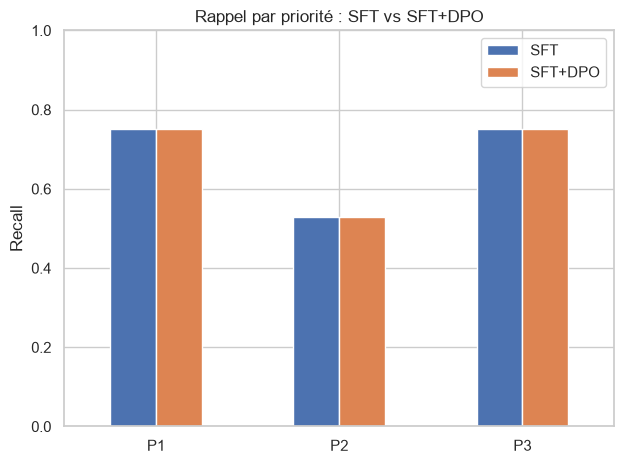

In [155]:
# Compare les métriques sur exactement les mêmes observations.
# Delta positif = gain, sauf invalid_rate où une baisse est favorable.
comparison_keys = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
    "invalid_rate",
    "precision_p1",
    "recall_p1",
    "f1_p1",
    "precision_p2",
    "recall_p2",
    "f1_p2",
    "precision_p3",
    "recall_p3",
    "f1_p3"
]

comparison_df = pd.DataFrame({
    "metric": comparison_keys,
    "SFT": [sft_metrics[key] for key in comparison_keys],
    "SFT+DPO": [dpo_metrics[key] for key in comparison_keys]
})

comparison_df["delta"] = (
    comparison_df["SFT+DPO"] - comparison_df["SFT"]
)

display(
    comparison_df.style.format({
        "SFT": "{:.4f}",
        "SFT+DPO": "{:.4f}",
        "delta": "{:+.4f}"
    })
)

comparison_df.to_csv(
    METRIC_DIR / "sft_dpo_metrics_comparison.csv",
    index=False,
    encoding="utf-8"
)

# Journalise la comparaison détaillée.
if dpo_run:
    dpo_run.log({
        "comparison/metrics": wandb.Table(
            dataframe=comparison_df
        )
    })

# Compare visuellement le rappel P1/P2/P3.
recall_df = comparison_df[
    comparison_df["metric"].isin(
        ["recall_p1", "recall_p2", "recall_p3"]
    )
].set_index("metric")

ax = recall_df[["SFT", "SFT+DPO"]].plot.bar()

ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("Recall")
ax.set_title("Rappel par priorité : SFT vs SFT+DPO")

plt.xticks(
    ticks=range(3),
    labels=["P1", "P2", "P3"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [156]:
# Compare le sous-triage avant et après DPO.
# Un delta négatif indique une réduction du risque.
undertriage_comparison = sft_undertriage[
    ["transition", "count", "rate_pct"]
].merge(
    dpo_undertriage[
        ["transition", "count", "rate_pct"]
    ],
    on="transition",
    suffixes=("_sft", "_sft_dpo"),
    validate="one_to_one"
)

undertriage_comparison["count_delta"] = (
    undertriage_comparison["count_sft_dpo"]
    - undertriage_comparison["count_sft"]
)

undertriage_comparison["rate_delta"] = (
    undertriage_comparison["rate_pct_sft_dpo"]
    - undertriage_comparison["rate_pct_sft"]
).round(2)

display(undertriage_comparison)

undertriage_comparison.to_csv(
    METRIC_DIR / "sft_dpo_undertriage_comparison.csv",
    index=False,
    encoding="utf-8"
)

# Journalise la comparaison du sous-triage.
if dpo_run:
    dpo_run.log({
        "comparison/undertriage": wandb.Table(
            dataframe=undertriage_comparison
        )
    })

,transition,count_sft,rate_pct_sft,count_sft_dpo,rate_pct_sft_dpo,count_delta,rate_delta
0,P1 → INVALID,3,1.79,3,1.79,0,0.0
1,P1 → P2,15,8.93,15,8.93,0,0.0
2,P1 → P3,24,14.29,24,14.29,0,0.0
3,P2 → INVALID,2,1.19,2,1.19,0,0.0
4,P2 → P3,34,20.24,34,20.24,0,0.0
5,P1 → priorité inférieure,39,23.21,39,23.21,0,0.0


In [157]:
# Compare les succès SFT et SFT+DPO avec le test exact de McNemar.
# Analyse aussi les transitions de prédictions entre les deux modèles.
paired = sft_results_df[
    ["id", "expected", "predicted"]
].merge(
    dpo_results_df[["id", "predicted"]],
    on="id",
    suffixes=("_sft", "_sft_dpo"),
    validate="one_to_one"
)

paired["sft_correct"] = (
    paired["expected"] == paired["predicted_sft"]
)

paired["sft_dpo_correct"] = (
    paired["expected"] == paired["predicted_sft_dpo"]
)

sft_only = int(
    (paired["sft_correct"] & ~paired["sft_dpo_correct"]).sum()
)

sft_dpo_only = int(
    (~paired["sft_correct"] & paired["sft_dpo_correct"]).sum()
)

discordant = sft_only + sft_dpo_only

mcnemar_pvalue = (
    binomtest(sft_dpo_only, discordant, p=0.5).pvalue
    if discordant
    else 1.0
)

# Construit les transitions SFT → SFT+DPO.
transition_table = pd.crosstab(
    paired["predicted_sft"],
    paired["predicted_sft_dpo"],
    rownames=["SFT"],
    colnames=["SFT+DPO"],
    dropna=False
)

display(transition_table)

print(f"SFT correct seul     : {sft_only:,}")
print(f"SFT+DPO correct seul : {sft_dpo_only:,}")
print(f"Discordants          : {discordant:,}")
print(f"McNemar exact p-value: {mcnemar_pvalue:.6f}")

# Sauvegarde les résultats.
transition_table.to_csv(
    METRIC_DIR / "sft_dpo_prediction_transitions.csv",
    encoding="utf-8"
)

mcnemar_results = {
    "sft_only_correct": sft_only,
    "sft_dpo_only_correct": sft_dpo_only,
    "discordant": discordant,
    "p_value": float(mcnemar_pvalue)
}

(METRIC_DIR / "sft_dpo_mcnemar.json").write_text(
    json.dumps(mcnemar_results, indent=2),
    encoding="utf-8"
)

# Journalise avant la fermeture du run DPO.
if dpo_run:
    dpo_run.log({
        "comparison/mcnemar_pvalue": mcnemar_pvalue,
        "comparison/sft_only_correct": sft_only,
        "comparison/sft_dpo_only_correct": sft_dpo_only,
        "comparison/discordant": discordant,
        "comparison/prediction_transitions": wandb.Table(
            dataframe=transition_table.reset_index()
        )
    })

SFT+DPO,0,1,2,3
SFT,,,,
0,7,0,0,0
1,0,184,0,0
2,0,0,129,0
3,0,0,0,184


SFT correct seul     : 0
SFT+DPO correct seul : 0
Discordants          : 0
McNemar exact p-value: 1.000000


TypeError: '<' not supported between instances of 'int' and 'str'

In [ ]:
# Résume factuellement l'effet du DPO sur le test commun.
# Le rappel P1 reste prioritaire, sans masquer les autres métriques.
macro_delta = dpo_metrics["f1_macro"] - sft_metrics["f1_macro"]
p1_recall_delta = dpo_metrics["recall_p1"] - sft_metrics["recall_p1"]

if macro_delta > 0 and p1_recall_delta > 0:
    conclusion = (
        "SFT+DPO améliore le macro-F1 et le rappel P1 "
        "sur le test commun."
    )
elif p1_recall_delta > 0:
    conclusion = (
        "SFT+DPO améliore le rappel P1, mais le macro-F1 "
        "ne progresse pas."
    )
elif macro_delta > 0:
    conclusion = (
        "SFT+DPO améliore le macro-F1, mais pas le rappel P1."
    )
else:
    conclusion = (
        "SFT+DPO n’améliore ni le macro-F1 ni le rappel P1 "
        "sur ce test."
    )

print(conclusion)
print(
    "Conclusion à compléter par la matrice de confusion, "
    "le sous-triage et l’analyse des erreurs."
)

comparison_payload = {
    "macro_f1_delta": float(macro_delta),
    "p1_recall_delta": float(p1_recall_delta),
    "mcnemar_pvalue": float(mcnemar_pvalue),
    "sft_only_correct": sft_only,
    "sft_dpo_only_correct": sft_dpo_only,
    "conclusion": conclusion
}

(METRIC_DIR / "sft_dpo_conclusion.json").write_text(
    json.dumps(
        comparison_payload,
        ensure_ascii=False,
        indent=2
    ),
    encoding="utf-8"
)

# Journalise la synthèse puis ferme définitivement W&B.
if dpo_run:
    dpo_run.log({
        **{
            f"comparison/{key}": value
            for key, value in comparison_payload.items()
            if isinstance(value, (int, float))
        },
        "comparison/table": wandb.Table(
            dataframe=comparison_df
        )
    })

    dpo_run.summary["conclusion"] = conclusion
    dpo_run.summary["best_checkpoint"] = (
        dpo_trainer.state.best_model_checkpoint
    )
    dpo_run.summary["best_eval_loss"] = (
        dpo_trainer.state.best_metric
    )

    dpo_run.finish()

print("✓ Comparaison SFT / SFT+DPO terminée")
print("✓ Run DPO W&B fermé")

## 12. Conclusion et manifeste

Je termine en sauvegardant les versions, empreintes, chemins et métriques. Ce manifeste permet de relier un résultat aux données, aux adaptateurs et au groupe W&B qui l’ont produit.


In [ ]:
# Le manifeste final rassemble les éléments nécessaires à la reproductibilité.
# Il ne contient aucun secret ni texte clinique brut.
manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "run_group": RUN_GROUP,
    "wandb_project": WANDB_PROJECT if USE_WANDB else None,
    "configuration": asdict(CONFIG),
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "gpu": torch.cuda.get_device_name(DEVICE_INDEX)
    },
    "data": {
        "sft_path": str(SFT_PATH),
        "sft_sha256": file_sha256(SFT_PATH),
        "dpo_path": str(DPO_PATH),
        "dpo_sha256": file_sha256(DPO_PATH),
        "test_rows": len(test_df),
        "dpo_leakage_removed": leakage_count
    },
    "models": {
        "sft_adapter": str(SFT_MODEL_PATH),
        "dpo_adapter": str(DPO_MODEL_PATH)
    },
    "results": {
        "sft": sft_metrics,
        "dpo": dpo_metrics,
        "comparison": comparison_payload
    }
}
MANIFEST_PATH = OUTPUT_DIR / "experiment_manifest.json"
MANIFEST_PATH.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")

print("=== CONCLUSION ===")
print(conclusion)
print(f"Manifest : {MANIFEST_PATH}")
print(f"Groupe W&B : {RUN_GROUP}")


### Points à vérifier avant une utilisation réelle

- Je dois faire relire les erreurs P1 par une personne compétente en triage médical.
- Je dois confirmer que les classes et consignes représentent bien le protocole clinique visé.
- Je dois répéter l’expérience sur plusieurs graines et sur un jeu externe indépendant.
- Je ne déploie pas ce prototype sans validation réglementaire, sécurité, confidentialité et supervision humaine.

Références techniques : [TRL SFTTrainer](https://huggingface.co/docs/trl/main/en/sft_trainer), [TRL DPOTrainer](https://huggingface.co/docs/trl/main/en/dpo_trainer), [W&B × Transformers](https://docs.wandb.ai/models/integrations/huggingface), [quantification bitsandbytes](https://huggingface.co/docs/transformers/main/en/quantization/bitsandbytes).
